In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from matplotlib.legend_handler import HandlerBase
import os
import numpy as np
import PyWGCNA
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score
from scipy.stats import mannwhitneyu, false_discovery_control
import re
from itertools import combinations
from scipy.stats import pearsonr, spearmanr
import ast
from matplotlib import patches
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines.plotting import add_at_risk_counts
import matplotlib.patheffects as path_effects  # Import PathEffects for text outlines
from matplotlib.gridspec import GridSpec

In [9]:
def stack_triangle(df, col):
    df = pd.DataFrame(
        df.where(
            np.tri(
                df.shape[0],
                dtype=bool,
                k=-1
            ),
            np.nan
        ).stack(dropna=True), columns=[col] 
    )
    
    return df


In [10]:
# Function that generates and saves the ROC curve
def generate_roc_curve(
    data,
    target_col,
    feature_col,
):
    # ROC curve using all gene pairs
    fpr, tpr, thr = roc_curve(data[target_col], data[feature_col])
    auroc = roc_auc_score(data[target_col], data[feature_col])
    
    return fpr, tpr, thr, auroc

In [11]:
def fig_to_panels(fig, axes, output_dir):
    # Save individual panels of a figure 
    
    os.makedirs(output_dir, exist_ok=True)
    
    for panel_name, ax in axes.items():
        # Extract the panel title
        panel_title = ax.get_title()

        # Sanitize the panel title to use in filenames
        safe_title = panel_title.replace(" ", "_").replace("/", "_").replace("\n", "_").lower()

        # Create the filename for the current panel
        output_file = os.path.join(output_dir,safe_title)

        # Adjust the bounding box to include everything (labels, titles, etc.)
        extent = ax.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())

        # Save the individual panel using the adjusted bounding box
        fig.savefig(output_file + '.pdf', bbox_inches=extent, dpi=300)
        fig.savefig(output_file + '.png', bbox_inches=extent)

        print(f"Saved panel '{panel_title}' to {output_file}")


In [12]:
# Define colors
# Light version is obtained by setting alpha=0.5

ncolor  = '#00728eff' # solid dark
ncolor2 = '#00728e80' # alpha=0.5
lightncolor = '#7fb8c6ff' # solid light

tcolor  = '#ab3502ff'
tcolor2 = '#ab350280'
lighttcolor = '#d49980ff'

graycolor = '#4D4E4FFF'
graycolor2 ='#4d4e4f80'

lightgray = '#C8CAD4'

orangecolor = '#e69426'
orangecolor2 = '#e6942680'
lightorangecolor = '#f2c992ff'

In [13]:
def network_to_adj(network_path):
    network = pd.read_csv(
        network_path,
        usecols=['complex1', 'complex2', 'adj']
    )

    # Add a mirrored version of the network to make it symmetric
    network_mirrored = network.copy()
    network_mirrored.columns = ['complex2', 'complex1', 'adj']
    network = pd.concat([network, network_mirrored], ignore_index=True)

    adj = network.pivot(index='complex1', columns='complex2', values='adj').fillna(0)
    return adj

In [14]:
replace = {
    'Myc': 'MYC',
    'Kras': 'KRAS',
    'Il2': 'IL2',
    'Stat5': 'STAT5',
    'Il6': 'IL6',
    'Jak': 'JAK',
    'Stat3': 'STAT3',
    'P53': 'P53',
    'Tnfa': 'TNFα',
    'Nfkb': 'NF-κB',
    'Mtorc1': 'mTORC1',
    'Mtorc': 'mTORC',
    'Mtor': 'mTOR',
    ' Dn': ' Down',
    'Pi3K': 'PI3K',
    ' Akt': ' AKT',
    'Epithelial Mesenchymal Transition': 'E-M Transition'
}

# Survival functions

In [15]:
def survival(interactions, df):
    import pandas as pd
    from lifelines import KaplanMeierFitter
    import re   
    
    df = df.copy()
    
    # Extract genes from the interaction string
    genes = list(set(re.split(r'[+&_]', interactions)))

    # Check if there are multiple conditions
    multiple_conditions = len(df['condition'].unique()) > 1

    # Filter and process the DataFrame
    cols = ['OS.time', 'OS', 'condition'] + genes
    df = df[cols]

    # Convert columns to numeric, except for condition
    df.loc[:, [col for col in df.columns if col != 'condition']] = (
        df.loc[:, [col for col in df.columns if col != 'condition']].apply(pd.to_numeric, errors='coerce')
    )
    df = df.dropna()

    # Convert OS time to years
    df['OS.time'] = df['OS.time'] / 365

    high_expression_group = pd.DataFrame()
    low_expression_group = pd.DataFrame()

    if multiple_conditions:
        # If there are multiple conditions, split the patients based on each condition
        for condition in df['condition'].unique():
            condition_df = df[df['condition'] == condition]
            
            # Calculate medians for each gene within the condition
            medians = condition_df[genes].median()
            
            # Identify patients above/below the median for all genes
            high_expression = condition_df[(condition_df[genes] > medians).T.all()]
            low_expression = condition_df[(condition_df[genes] <= medians).T.all()]
            
            # Append to the respective groups
            high_expression_group = pd.concat([high_expression_group, high_expression])
            low_expression_group = pd.concat([low_expression_group, low_expression])
    else:
        # If there is only one condition, split based on the entire dataset
        medians = df[genes].median()
        high_expression_group = df[(df[genes] > medians).T.all()]
        low_expression_group = df[(df[genes] <= medians).T.all()]

    # Remove patients that are in both groups
    common_patients = high_expression_group.index.intersection(low_expression_group)
    high_expression_group = high_expression_group[~high_expression_group.index.isin(common_patients)]
    low_expression_group  = low_expression_group[ ~low_expression_group.index.isin( common_patients)]
        
    # Count number of patients
    n_patients_low = low_expression_group.shape[0]
    n_patients_high = high_expression_group.shape[0]

    # Fit the Kaplan-Meier estimators
    kmf_low = KaplanMeierFitter()
    kmf_high = KaplanMeierFitter()

    kmf_low.fit(
        low_expression_group['OS.time'],
        event_observed=low_expression_group['OS'],
        label="Low Expression"
    )
    kmf_high.fit(
        high_expression_group['OS.time'],
        event_observed=high_expression_group['OS'],
        label="High Expression"
    )

    return {
        'name': interactions,
        'kmf_low': kmf_low,
        'kmf_high': kmf_high,
        'low_expression': low_expression_group.index,
        'high_expression': high_expression_group.index,
    }

In [16]:
def get_genes(string):
    genes = list(re.split(r'[+&_]', string))

    # Remove duplicates while preserving order
    seen = set()
    ordered_genes = []
    for gene in genes:
        if gene not in seen:
            seen.add(gene)
            ordered_genes.append(gene)

    return ordered_genes

# THIS IS THE CORRECT ONE, REPLACE THE OTHERS
def plot_all_3(interaction, tissue, survival_df, axes, xlim=(0, 15), ylim=(0, 1.01), savepath=None,fs=14, smallfs=11):
        
    df = survival_df.copy()
    #df.index = df.index.str.rsplit(pat='-', n=1, expand=True).get_level_values(0)
    
    interaction_results = survival(interaction, df)
    int1, int2 = interaction.split('&')
    interaction_results1 = survival(int1, df)
    interaction_results2 = survival(int2, df)

    results_list = [interaction_results, interaction_results1, interaction_results2]

    for idx, (ax_box, ax_km) in enumerate(axes):
        result = results_list[idx]
        name = result['name']
        genes = get_genes(name)
        
        # Survival curve data
        pval = rawdf.set_index(['interaction', 'tissue']).loc[(name, tissue), 'logrank_pval']
        n_low = rawdf.set_index(['interaction', 'tissue']).loc[(name, tissue), 'n_patients_low']
        n_high = rawdf.set_index(['interaction', 'tissue']).loc[(name, tissue), 'n_patients_high']

        ax_km.set_xlim(xlim)
        ax_km.set_ylim(ylim)

        ci = False
        censors = True
        result['kmf_low'].plot_survival_function(
            ax=ax_km, color=ncolor, ci_show=ci, show_censors=censors, linewidth=0.7,
            label='Low Expr.'.format(n_low), censor_styles={'ms': 5,'lw': 0.7},
        )
        result['kmf_high'].plot_survival_function(
            ax=ax_km, color=tcolor, ci_show=ci, show_censors=censors, linewidth=0.7,
            label='High Expr.'.format(n_high), censor_styles={'ms': 5, 'lw': 0.7},
        )

        ax_km.set_xlabel('Time (Years)', fontsize=smallfs)
        ax_km.set_ylabel('Survival Prob.', fontsize=smallfs)
        ax_km.legend(fontsize=smallfs, framealpha=0.5, loc='upper right') 

        ypos = ax_km.get_ylim()[0] + 0.06 * (ax_km.get_ylim()[1] - ax_km.get_ylim()[0])
        xpos = ax_km.get_xlim()[0] + 0.015 * (ax_km.get_xlim()[1] - ax_km.get_xlim()[0])
        text = ax_km.text(xpos, ypos, '$p={:.1e}$'.format(pval), fontsize=smallfs)
        text.set_path_effects([
            path_effects.Stroke(linewidth=5, foreground=(1,1,1,0.5)),
            path_effects.Normal()
        ])

        # Expression boxplot — using survival groups
        df['Group'] = np.nan
        df.loc[df.index.isin(result['high_expression']), 'Group'] = 'High Expression'
        df.loc[df.index.isin(result['low_expression']), 'Group'] = 'Low Expression'
        # Only keep patients used in survival
        survival_patients = df[df['Group'].notna()]
        violindata = survival_patients.melt(id_vars=['Group'], value_vars=genes)
        violindata['variable'] = pd.Categorical(violindata['variable'], categories=genes, ordered=True)
        
        sns.boxplot(
            data=violindata,
            x='variable',
            y='value',
            hue='Group',
            palette={'High Expression': tcolor, 'Low Expression': ncolor},
            order=genes,
            fliersize=0,
            ax=ax_box
        )
        
        #ax_box.set_xlabel('Gene', fontsize=fs)
        ax_box.set_xlabel('')
        ax_box.set_ylabel('log2(0.001 + TPM)', fontsize=smallfs)
        ax_box.get_legend().remove()

        # Format spines and ticks
        for axis in [ax_box, ax_km]:
            axis.tick_params(bottom=True, left=True, axis='both', which='both', direction='out', length=2, width=1, colors='black', labelsize=smallfs)
            axis.spines[['right', 'top']].set_visible(False)
            axis.spines[['left', 'bottom']].set_color('black')

        ax_box.tick_params(axis='x', direction='out', labelsize=smallfs, length=2, width=1, colors='black', rotation=45)
        for label in ax_box.get_xticklabels():
            label.set_ha('right')
        
        add_at_risk_counts(result['kmf_low'], result['kmf_high'], ax=ax_km, ypos=-0.075, rows_to_show=['At risk'], fontsize=smallfs)

    
    # Set all titles
    for idx, (ax_box, ax_km) in enumerate(axes):
        title = tissue.replace('_', ' ').title().replace(' And ', ' & ') + ', '
        if idx == 0:
            title += interaction.replace('&', ' & ').replace('+', ' - ').replace('_', ' - ')
        else:
            title += interaction.split('&')[idx-1].replace('+', ' - ').replace('_', ' - ')
        ax_km.set_title(title, fontsize=fs)

    if savepath is not None:
        plt.savefig(savepath + '.pdf', bbox_inches='tight')
        plt.savefig(savepath + '.png', bbox_inches='tight')


# Motifs Survival

In [17]:
rawdf = pd.read_csv('/home/lnemati/pathway_crosstalk/results/survival/aggregate/all_unfiltered.csv')
crosstalkdf = pd.read_csv('/home/lnemati/pathway_crosstalk/results/survival/aggregate/all_pairs.csv')

significant = crosstalkdf.query('pval_adj < 0.05')
significant = significant.query('not ((hr - se) < 1 and 1 < (hr + se))')

better = significant.copy()
better = better.query('hr_lfc_best > 0.')
better = better.query('c_diff_best > 0.')
better = better.query('(logrank_pval < logrank_pval1) and (logrank_pval < logrank_pval2)')

# Read coariates analysis
import pandas as pd
from pathlib import Path
from scipy.stats import false_discovery_control

parent_dir = Path('/home/lnemati/pathway_crosstalk/results/survival/covariates')

# find all csv files
csv_files = parent_dir.glob('*.csv')

# read and combine
covdf = pd.concat((pd.read_csv(file) for file in csv_files), ignore_index=True)

# there are a few NaNs (e.g. model did not converge), drop them
covdf = covdf.dropna()

# Adjust pvalues
covdf['lrt_pval_adj'] = false_discovery_control(covdf['lrt_pval'])
covdf['lrt_significant'] = covdf['lrt_pval_adj'] < 0.05

# Add covariate columns to better df
covdf = covdf[['interaction', 'tissue', 'aic_lower', 'lrt_significant', 'lrt_pval_adj', 'covariates_used']].set_index(['interaction', 'tissue'])
better = better.join(covdf, on=['interaction', 'tissue'])

cliques = better.query('tissue != "Pan_Cancer" and motif in ["3_clique", "4_clique"]')

#better.to_csv('/home/lnemati/pathway_crosstalk/results/survival/aggregate/better_pairs.csv', index=False)
#better.query('motif in ["3_clique", "4_clique"]').to_csv('/home/lnemati/pathway_crosstalk/results/survival/aggregate/better_cliques.csv', index=False)

better.head(3)

,interaction,tissue,hr,hr1,hr2,concordance_index,concordance_index1,concordance_index2,logrank_pval,logrank_pval1,...,log2_hr1,log2_hr2,pval_adj,hr_lfc_best,c_diff_best,motif,aic_lower,lrt_significant,lrt_pval_adj,covariates_used
0,ADA+ADORA2B&FBN1+ITGA5_ITGB1,Pan_Cancer,2.473422,1.449832,1.453431,0.525176,0.520904,0.522021,1.996489e-290,2.866094e-192,...,0.535886,0.539462,1.599185e-284,0.767046,0.003155,4_path,NaN,NaN,NaN,NaN
1,COL6A3+ITGA10_ITGB1&ADA+ADORA2B,Pan_Cancer,2.690729,1.434415,1.449832,0.522922,0.516268,0.520904,2.855622e-255,2.507191e-171,...,0.520463,0.535886,1.143675e-249,0.892112,0.002018,4_no_crosstalk,NaN,NaN,NaN,NaN
2,FN1+ITGA11_ITGB1&ADA+ADORA2B,Pan_Cancer,2.452652,1.395628,1.449832,0.526302,0.520509,0.520904,1.348607e-251,3.625836e-201,...,0.480914,0.535886,3.600776e-246,0.758457,0.005398,4_no_crosstalk,NaN,NaN,NaN,NaN


In [18]:
#crosstalkdf.to_csv('/home/lnemati/pathway_crosstalk/results/survival/all_pairs_survival.csv')

In [19]:
df = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/tumor/motifs_permutations.csv')
motifs = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/tumor/counts.csv', index_col='motif')
motifs = motifs['number'] 

df3 = df[[col for col in df.columns if col.startswith('3')]]
df4 = df[[col for col in df.columns if col.startswith('4')]]
motifs3 = motifs.loc[[idx for idx in motifs.index if idx.startswith('3')]]
motifs4 = motifs.loc[[idx for idx in motifs.index if idx.startswith('4')]]

motifs3 = motifs3 / motifs3.sum()
motifs4 = motifs4 / motifs4.sum()
df3 = (df3.T / df3.sum(1)).T
df4 = (df4.T / df4.sum(1)).T

df = df3.join(df4)
motifs = pd.concat([motifs3, motifs4])

means = df.mean()
stds = df.std()

motifs_z = ((motifs - means) / stds).sort_values()
motifs_z.name = 'z'

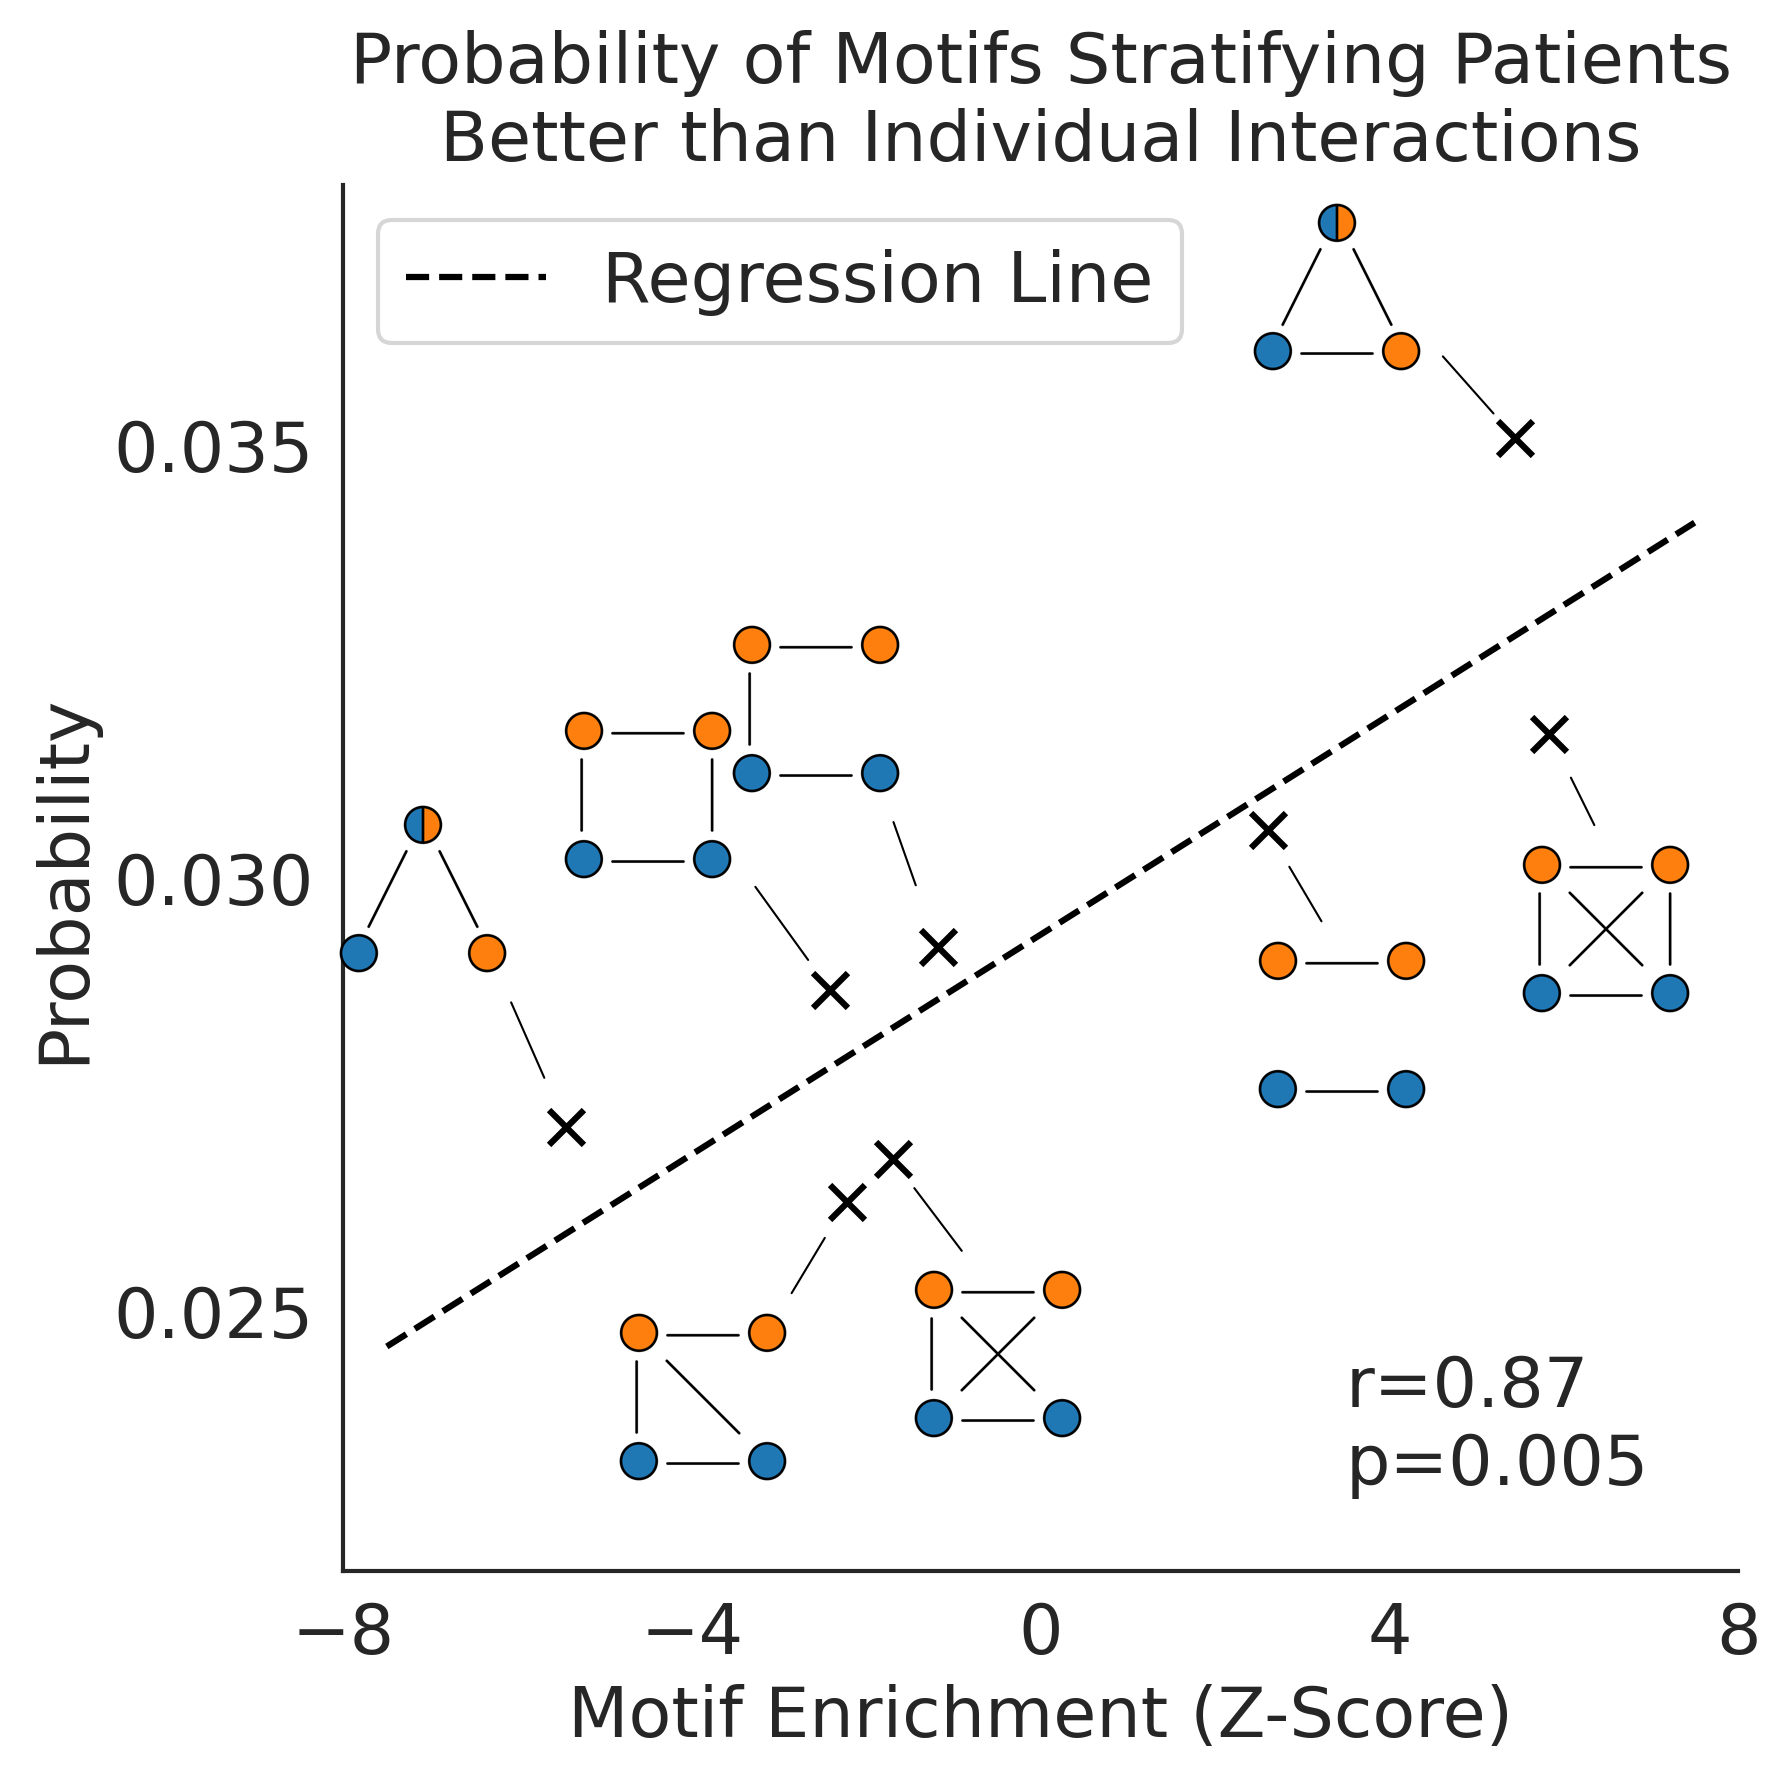

In [20]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import image as mpimg
import os
from PIL import Image

# Constants
dpi = 300
img_dir = '/home/lnemati/pathway_crosstalk/data/motifs_icons/'  # Update this path
image_scaling_factor = 0.3  # Adjust this factor to scale image size (smaller = more zoomed out)
x_offset = -25
y_offset = 250

fs = 14/5 * 6

# Filter data
df = better.query('tissue != "Pan_Cancer"')
all_counts = crosstalkdf.query('tissue != "Pan_Cancer"').motif.value_counts().sort_values(ascending=False)

# Calculate probabilities
probs = (df.motif.value_counts() / all_counts).sort_values()
probs = probs.loc[motifs_z.index]

data = pd.DataFrame()
data['z'] = motifs_z
data['prob'] = probs

# Calculate Pearson correlation
r_value, p_r_value = pearsonr(data['prob'], data['z'])
rho_value, p_rho_value = spearmanr(data['prob'], data['z'])

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(6, 6), dpi=dpi)

# Plot the scatter points
#ax.scatter(
#    data['z'], 
#    data['prob'], 
#    color=lightgray, 
#    marker='s', 
#    edgecolors='black',  # Black edge color
#    s=70,
#    linewidths=1.5  # Thickness of the edge
#)
ax.scatter(
    data['z'], 
    data['prob'], 
    #color='black', 
    color='black', 
    marker='x', 
    edgecolors='black',  # Black edge color
    s=70,
    linewidths=1.5  # Thickness of the edge
)

# Add Pearson correlation to plot
ax.text(3.5, 0.023, 'r={:.2f}\np={:.3f}'.format(r_value, p_r_value), fontsize=fs)
#ax.text(7, 0.0225, fr"Spearman's $\rho$ = {rho_value:.2f}" + '\n' + f'p-value = {p_rho_value:.2f}', fontsize=fs, ha='right')

# Set limits and ticks
ax.set_xlim(-8, 8)
ax.set_ylim(0.022, 0.038)
xticks = [-8, -4, 0, 4, 8]
yticks = [0.025, 0.030, 0.035]
ax.set_xticks(xticks)
ax.set_yticks(yticks)

# Hide top and right spines
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(labelsize=fs)

# Add title and labels
ax.set_title('Probability of Motifs Stratifying Patients\nBetter than Individual Interactions', fontsize=fs)
ax.set_xlabel('Motif Enrichment (Z-Score)', fontsize=fs)
ax.set_ylabel('Probability', fontsize=fs)

# Make the background of the plot transparent so the images can show up
ax.patch.set_alpha(0)

# Get the regression line parameters (slope and intercept)
slope, intercept = np.polyfit(data['z'], data['prob'], 1)

# Extend the regression line beyond the data range
x_extended = np.linspace(ax.get_xlim()[0] + 0.5, ax.get_xlim()[1] - 0.5, 100)
y_extended = slope * x_extended + intercept
ax.plot(x_extended, y_extended, linestyle='--', color='k', linewidth=1.5, label='Regression Line', zorder=-10)

# Dictionary to define manual positions for each motif
motif_positions = {
    '3_path': (data['z']['3_path'], data['prob']['3_path']),
    '4_cycle': (data['z']['4_cycle']-0.45, data['prob']['4_cycle']-0.0005),
    '4_triangle_extra': (data['z']['4_triangle_extra'], data['prob']['4_triangle_extra']-0.005),
    '4_one_missing': (data['z']['4_one_missing']+2.85, data['prob']['4_one_missing']-0.005),
    '4_path': (data['z']['4_path']+0.25, data['prob']['4_path']),
    '4_no_crosstalk': (data['z']['4_no_crosstalk']+2.5, data['prob']['4_no_crosstalk']-0.005),
    '3_clique': (data['z']['3_clique']-0.4, data['prob']['3_clique']-0.001),
    '4_clique': (data['z']['4_clique']+2.3, data['prob']['4_clique']-0.005),
}

# Loop through each motif and place an image at the manually defined position
for motif, (x_pos, y_pos) in motif_positions.items():
    img_path = os.path.join(img_dir, f"{motif}.png")
    if os.path.exists(img_path):
        # Read image
        im = Image.open(img_path)
        
        # Resize the image (scale it down by the factor)
        width, height = im.size
        im_resized = im.resize((int(width * image_scaling_factor), int(height * image_scaling_factor)))

        # Convert resized image to numpy array for figimage
        im_resized = np.array(im_resized)

        # Transform plot coordinates to pixel coordinates
        pixel_pos = ax.transData.transform((x_pos, y_pos))
        
        # Place image at position (centered over the point) with scaled size
        fig.figimage(
            im_resized,
            pixel_pos[0] - im_resized.shape[1] / 2 + x_offset,
            pixel_pos[1] - im_resized.shape[0] / 2 + y_offset, 
            origin="upper"
        )

        line_frac = 0.5  # Fraction to remove from the image (icon) side
        marker_trim = 0.25  # Fixed distance to trim from the marker side (in data units)

        # Compute image center in pixel space
        img_center_x_pix = pixel_pos[0] - im_resized.shape[1] / 2 + x_offset
        img_center_y_pix = pixel_pos[1] + y_offset

        # Convert image center from pixel to data coordinates
        img_center_data = ax.transData.inverted().transform((img_center_x_pix, img_center_y_pix))

        # Coordinates of the start (marker) and end (image) of the full line
        x0, y0 = motifs_z.loc[motif], probs.loc[motif]  # marker
        x1, y1 = img_center_data                        # image

        # Vector from marker to image
        dx = x1 - x0
        dy = y1 - y0
        line_length = np.hypot(dx, dy)

        # Normalize direction vector
        dxn, dyn = dx / line_length, dy / line_length

        # Remove a fixed-length segment from the marker side
        x_start = x0 + dxn * marker_trim
        y_start = y0 + dyn * marker_trim

        # Remove a *fraction* of the total line length from the image side
        x_end = x1 - dxn * (line_frac * line_length)
        y_end = y1 - dyn * (line_frac * line_length)

        # Draw the trimmed line
        ax.plot([x_start, x_end], [y_start, y_end], color='k', linewidth=0.5, zorder=-5)

# Hide legend, as it may conflict with the images
#plt.legend([], [], frameon=False)
plt.legend(fontsize=fs, loc='upper left')

#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/survival/motifs_z_prob.pdf', bbox_inches='tight', dpi=dpi)
#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/survival/motifs_z_prob.png', bbox_inches='tight', dpi=dpi)

# Show the plot
plt.show()


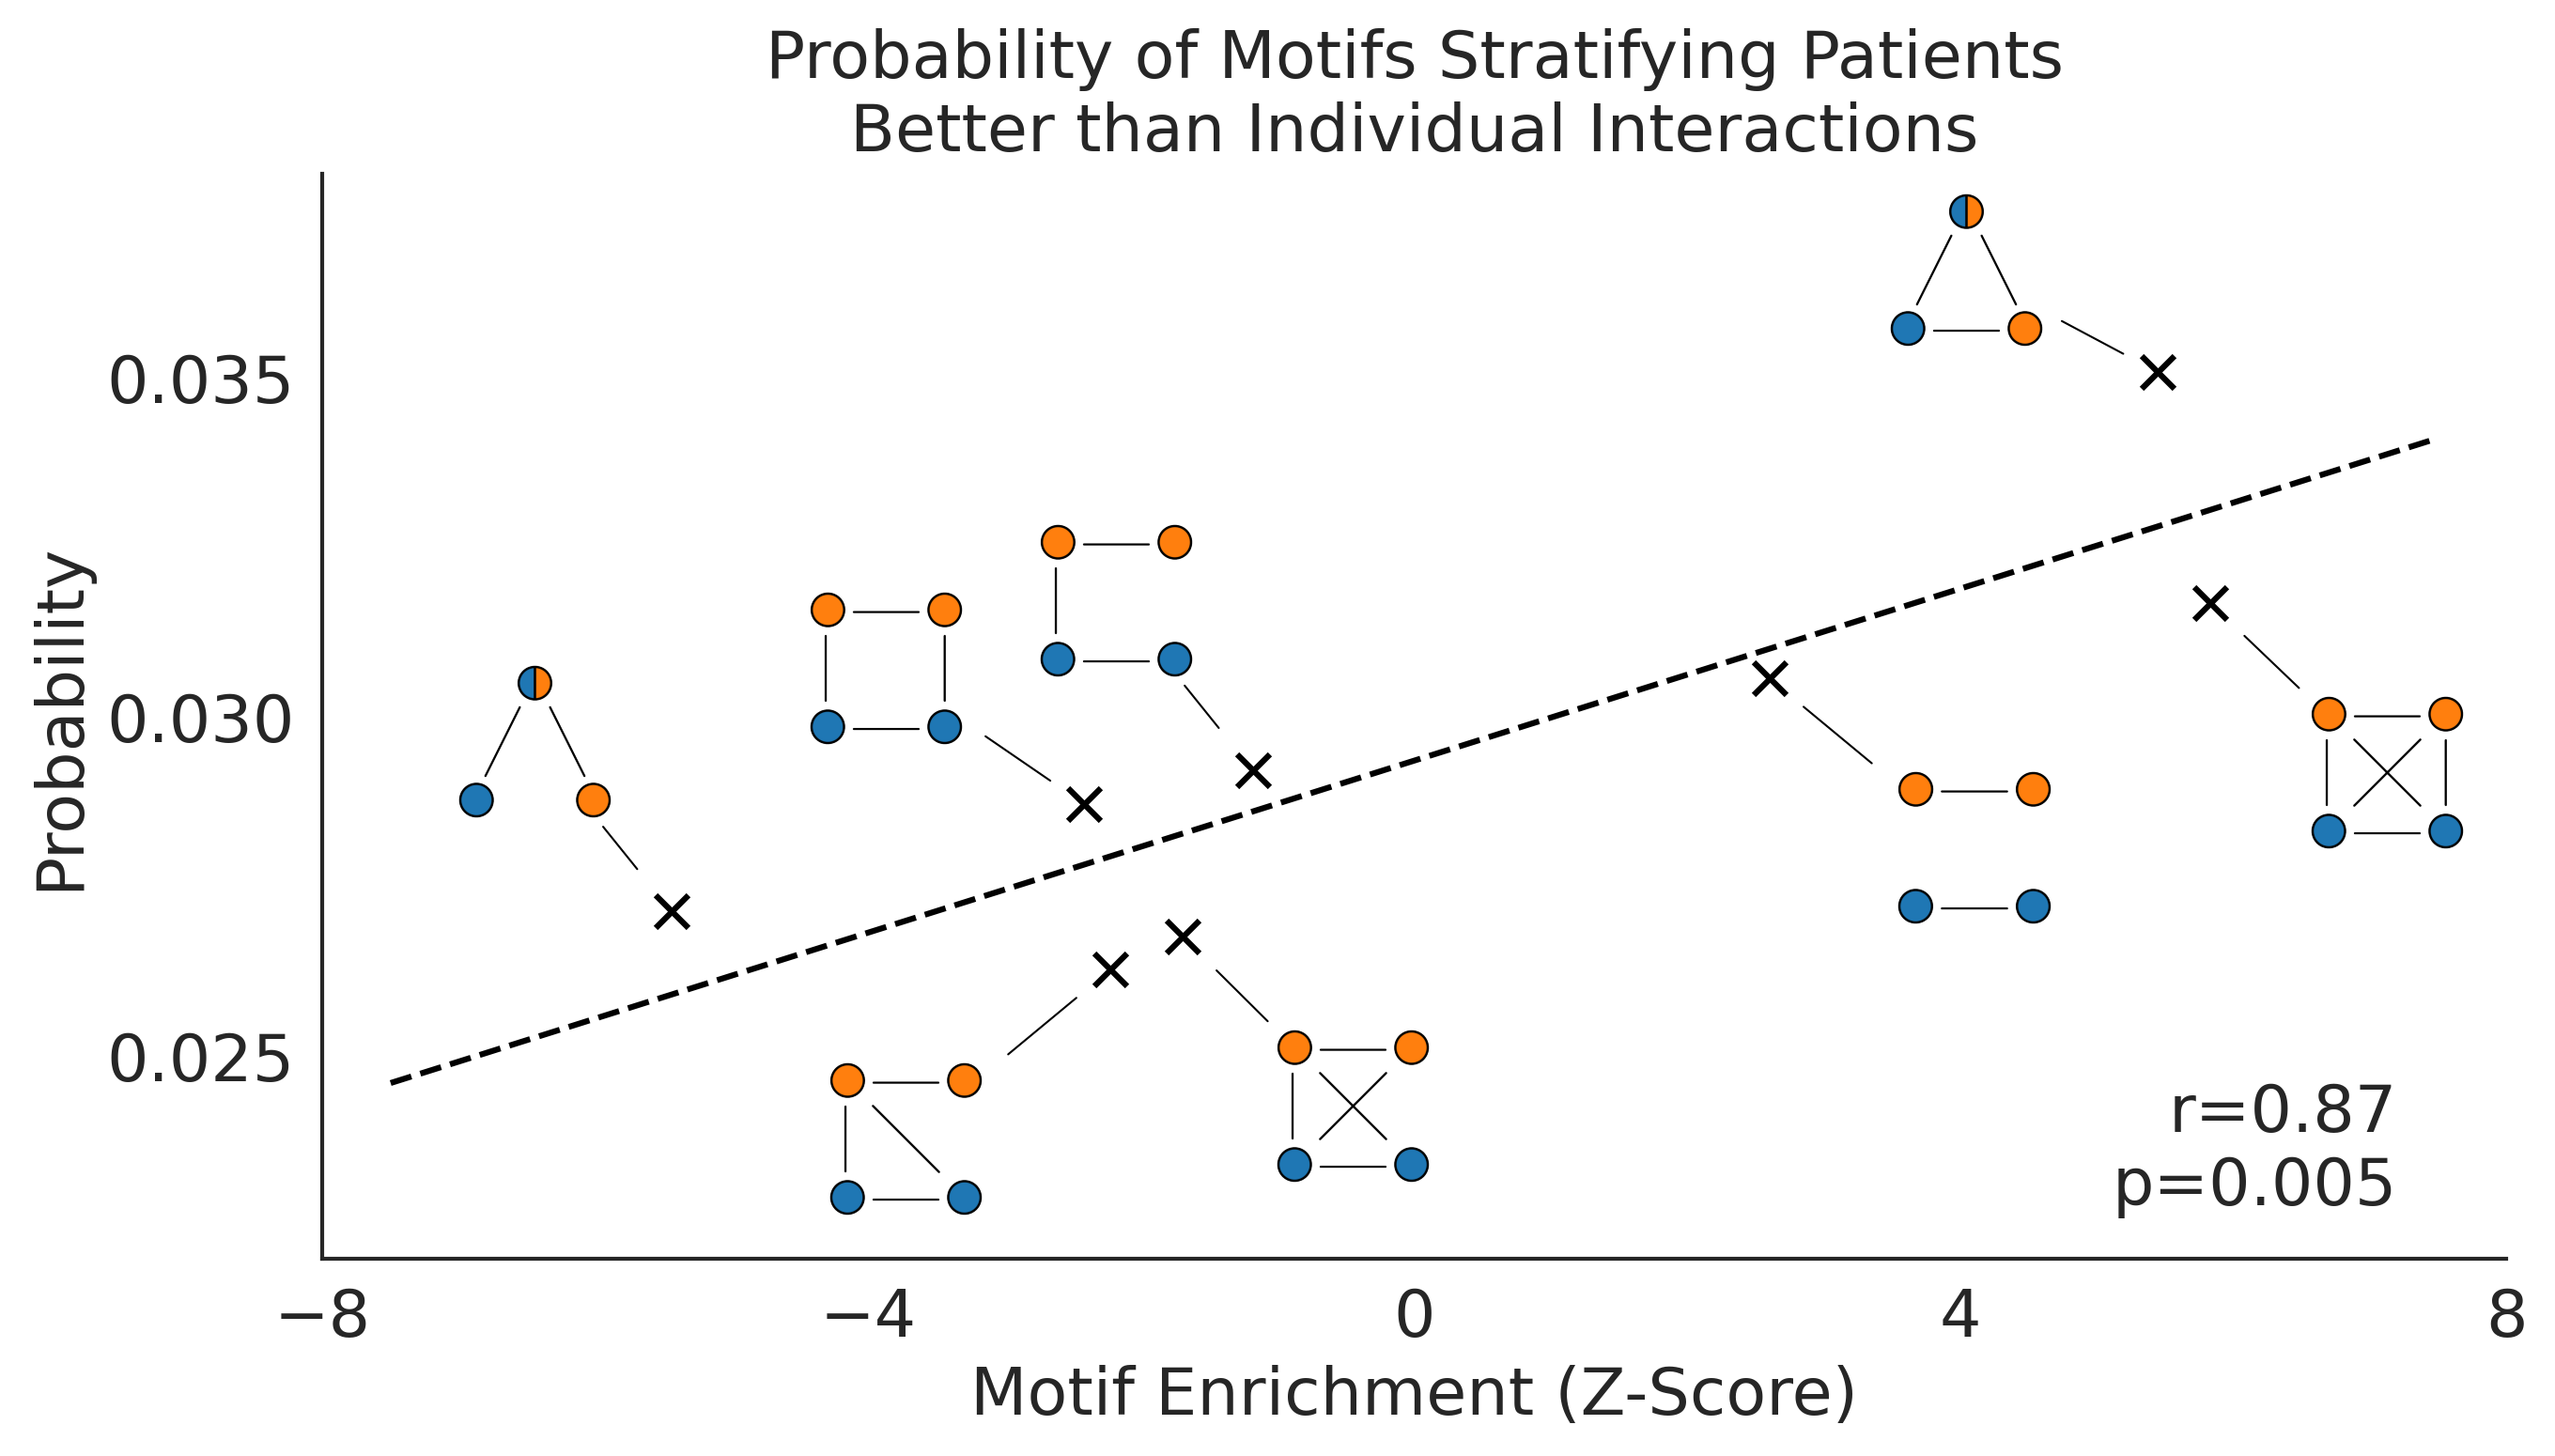

In [196]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import os
from scipy.stats import pearsonr, spearmanr

# --- Constants ---
dpi = 300
img_dir = '/home/lnemati/pathway_crosstalk/data/motifs_icons/'
image_scaling_factor = 0.55  # smaller for subplot usage
fs = 14 / 5 * 6

x_offset = -1
y_offset = 0.0025

# --- Filter Data ---
df = better.query('tissue != "Pan_Cancer"')
all_counts = crosstalkdf.query('tissue != "Pan_Cancer"').motif.value_counts().sort_values(ascending=False)
probs = (df.motif.value_counts() / all_counts).sort_values()
probs = probs.loc[motifs_z.index]

data = pd.DataFrame({'z': motifs_z, 'prob': probs})

# --- Correlation ---
r_value, p_r_value = pearsonr(probs, motifs_z)
rho_value, p_rho_value = spearmanr(probs, motifs_z)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5), dpi=dpi)

# Scatter
ax.scatter(data['z'], data['prob'], color='black', marker='x', s=70, linewidths=1.5)

# Correlation text
ax.text(0.95, 0.05, f'r={r_value:.2f}\np={p_r_value:.3f}',
        transform=ax.transAxes, fontsize=fs, ha='right')

# Axes settings
ax.set_xlim(-8, 8)
ax.set_ylim(0.022, 0.038)
ax.set_xticks([-8, -4, 0, 4, 8])
ax.set_yticks([0.025, 0.030, 0.035])
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(labelsize=fs)
ax.set_title('Probability of Motifs Stratifying Patients\nBetter than Individual Interactions', fontsize=fs)
ax.set_xlabel('Motif Enrichment (Z-Score)', fontsize=fs)
ax.set_ylabel('Probability', fontsize=fs)

# Regression line
slope, intercept = np.polyfit(data['z'], data['prob'], 1)
x_extended = np.linspace(ax.get_xlim()[0] + 0.5, ax.get_xlim()[1] - 0.5, 100)
y_extended = slope * x_extended + intercept
ax.plot(x_extended, y_extended, linestyle='--', color='k', linewidth=1.5, zorder=-10)

motif_positions = {
    '3_path': (data['z']['3_path'], data['prob']['3_path']),
    '4_cycle': (data['z']['4_cycle'] - 0.45, data['prob']['4_cycle'] - 0.0005),
    '4_triangle_extra': (data['z']['4_triangle_extra']-0.5, data['prob']['4_triangle_extra'] - 0.005),
    '4_one_missing': (data['z']['4_one_missing'] + 2.25, data['prob']['4_one_missing'] - 0.005),
    '4_path': (data['z']['4_path'], data['prob']['4_path']),
    '4_no_crosstalk': (data['z']['4_no_crosstalk'] + 2.5, data['prob']['4_no_crosstalk'] - 0.005),
    '3_clique': (data['z']['3_clique'] - 0.4, data['prob']['3_clique'] - 0.001),
    '4_clique': (data['z']['4_clique'] + 2.3, data['prob']['4_clique'] - 0.005),
}

#motif_positions = {k: (data['z'][k], data['prob'][k]) for k in data.index}

# --- Add motif icons using inset_axes ---
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

for motif, (x_pos, y_pos) in motif_positions.items():
    img_path = os.path.join(img_dir, f"{motif}.png")
    x_pos += x_offset
    y_pos += y_offset
    if os.path.exists(img_path):
        # Convert data coordinates to axis-relative
        inv = ax.transData.transform
        trans = ax.transAxes.inverted().transform
        ax_rel_coords = trans(inv((x_pos, y_pos)))

        # Create inset axes at that location
        ax_img = inset_axes(ax,
                            width=image_scaling_factor,
                            height=image_scaling_factor,
                            loc='center',
                            bbox_to_anchor=(ax_rel_coords[0], ax_rel_coords[1]),
                            bbox_transform=ax.transAxes,
                            borderpad=0)

        # Load and show image
        im = Image.open(img_path)
        ax_img.imshow(im)
        ax_img.axis('off')

        # Line from data point to image center
        x0, y0 = data['z'][motif], data['prob'][motif]  # data point
        x1, y1 = x_pos, y_pos  # image anchor
        dx, dy = x1 - x0, y1 - y0
        length = np.hypot(dx, dy)
        line_frac = 0.5
        marker_trim = 0.25
        dxn, dyn = dx / length, dy / length
        x_start, y_start = x0 + dxn * marker_trim, y0 + dyn * marker_trim
        x_end, y_end = x1 - dxn * (line_frac * length), y1 - dyn * (line_frac * length)
        ax.plot([x_start, x_end], [y_start, y_end], color='k', linewidth=0.5, zorder=-5)

# Legend (optional, usually omitted for clarity)
# ax.legend(fontsize=fs, loc='upper left')

# Save
#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/survival/motifs_z_prob_large.pdf', bbox_inches='tight', dpi=dpi)
#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/survival/motifs_z_prob_large.png', bbox_inches='tight', dpi=dpi)

plt.show()


In [21]:
probs

motif
3_path              0.027123
4_cycle             0.028707
4_triangle_extra    0.026266
4_one_missing       0.026755
4_path              0.029205
4_no_crosstalk      0.030559
3_clique            0.035080
4_clique            0.031669
Name: count, dtype: float64

# Barplot By Rank Aggregate of C Index and HR Increase

In [197]:
from matplotlib.legend_handler import HandlerBase

In [198]:
# Filter for desired motifs
barplotdf = better.query('motif in ["3_clique", "4_clique"] and aic_lower').copy()

# Compute ranks within each tissue (lower rank = better)
barplotdf['cindex_rank'] = barplotdf.groupby('tissue')['concordance_index'].rank(ascending=False)
barplotdf['hrlfc_rank'] = barplotdf.groupby('tissue')['hr_lfc_best'].rank(ascending=False)

# Combine the ranks (simple sum — you can customize this)
barplotdf['agg_rank'] = barplotdf['cindex_rank'] + barplotdf['hrlfc_rank']

# Get top 3 by aggregate rank per tissue
barplotdf = barplotdf.sort_values(by='agg_rank').groupby('tissue').head(3)

# Drop Pan_Cancer and clean tissue labels
barplotdf = barplotdf.query('tissue != "Pan_Cancer"')
barplotdf['tissue'] = barplotdf['tissue'].str.replace('_', ' ').str.replace(' And ', ' & ')

for idx, row in barplotdf.iterrows():
    # First interaction must be the closest to zero
    if np.abs(row['log2_hr1']) > np.abs(row['log2_hr2']):
        # reorder values
        val1, val2 = (row['log2_hr1'], row['log2_hr2'])
        barplotdf.at[idx, 'log2_hr1'] = val2
        barplotdf.at[idx, 'log2_hr2'] = val1
        # reorder name
        int1, int2 = row['interaction'].split('&')
        barplotdf.at[idx, 'interaction'] = int2 + '&' + int1
        
barplotdf['interaction'] = barplotdf.interaction.str.replace('_', ' - ').str.replace('+', ' - ').str.replace('&', ' & ')

In [199]:
import re

# Split interactions into individual genes for each side
barplotdf['interaction1'] = barplotdf.interaction.apply(lambda x: re.split('&', x)[0].strip().split(' - '))
barplotdf['interaction2'] = barplotdf.interaction.apply(lambda x: re.split('&', x)[1].strip().split(' - '))

# Load hallmark gene sets
def read_gmt(file_path):
    gene_sets = {}
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 3:
                gene_sets[parts[0]] = set(parts[2:])
    return gene_sets

hallmarks_path = '/home/lnemati/resources/msigdb_hallmarks/h.all.v2024.1.Hs.symbols.gmt'
hallmarks = read_gmt(hallmarks_path)

# Generate cleaned hallmark labels
labels = [label.replace('HALLMARK_', '').replace('_', ' ').title() for label in hallmarks.keys()]

replace = {
    'Myc': 'MYC',
    'Kras': 'KRAS',
    'Il2': 'IL2',
    'Stat5': 'STAT5',
    'Il6': 'IL6',
    'Jak': 'JAK',
    'Stat3': 'STAT3',
    'P53': 'P53',
    'Tnfa': 'TNFα',
    'Nfkb': 'NF-κB',
    'Mtorc1': 'mTORC1',
    'Mtorc': 'mTORC',
    'Mtor': 'mTOR',
    ' Dn': ' Down',
    'Pi3K': 'PI3K',
    ' Akt': ' AKT',
    'Epithelial Mesenchymal Transition': 'E-M Transition'
}

for str1, str2 in replace.items():
    labels = [label.replace(str1, str2) for label in labels]

hallmark_name_map = dict(zip(hallmarks.keys(), labels))

# Function to find matching hallmark sets for a given gene list
def find_matching_hallmarks(gene_list, hallmark_sets):
    return [name for name, genes in hallmark_sets.items() if set(gene_list) & genes]

# Get hallmarks for each side of the interaction
barplotdf['hallmarks1'] = barplotdf['interaction1'].apply(lambda genes: find_matching_hallmarks(genes, hallmarks))
barplotdf['hallmarks2'] = barplotdf['interaction2'].apply(lambda genes: find_matching_hallmarks(genes, hallmarks))

# Convert to readable labels using the name map
barplotdf['hallmarks1'] = barplotdf['hallmarks1'].apply(lambda hlist: [hallmark_name_map[h] for h in hlist])
barplotdf['hallmarks2'] = barplotdf['hallmarks2'].apply(lambda hlist: [hallmark_name_map[h] for h in hlist])

import numpy as np

# Define subset of hallmarks you want to consider (for example, top N or all unique found)
# For demonstration, use all unique hallmarks found across both sides:
all_hallmarks = sorted(set(sum(barplotdf['hallmarks1'], [])) | set(sum(barplotdf['hallmarks2'], [])))

# Initialize matrix: rows = interactions, columns = hallmarks
heatmap_matrix = np.zeros((len(barplotdf), len(all_hallmarks)), dtype=int)

# Fill matrix with presence codes
for i, row in enumerate(barplotdf.itertuples(index=False)):
    hallmarks_1 = set(row.hallmarks1)
    hallmarks_2 = set(row.hallmarks2)
    for j, hallmark in enumerate(all_hallmarks):
        in_1 = hallmark in hallmarks_1
        in_2 = hallmark in hallmarks_2
        heatmap_matrix[i, j] = 1 * in_1 + 2 * in_2  # 0, 1, 2, or 3

heatmap_df = pd.DataFrame(heatmap_matrix, index=barplotdf.interaction, columns=all_hallmarks)    
heatmap_df = heatmap_df[::-1] # Invert to match order of the plot

# Values:
# 0 = not present
# 1 = interaction1
# 2 = interaction2
# 3 = both interactions


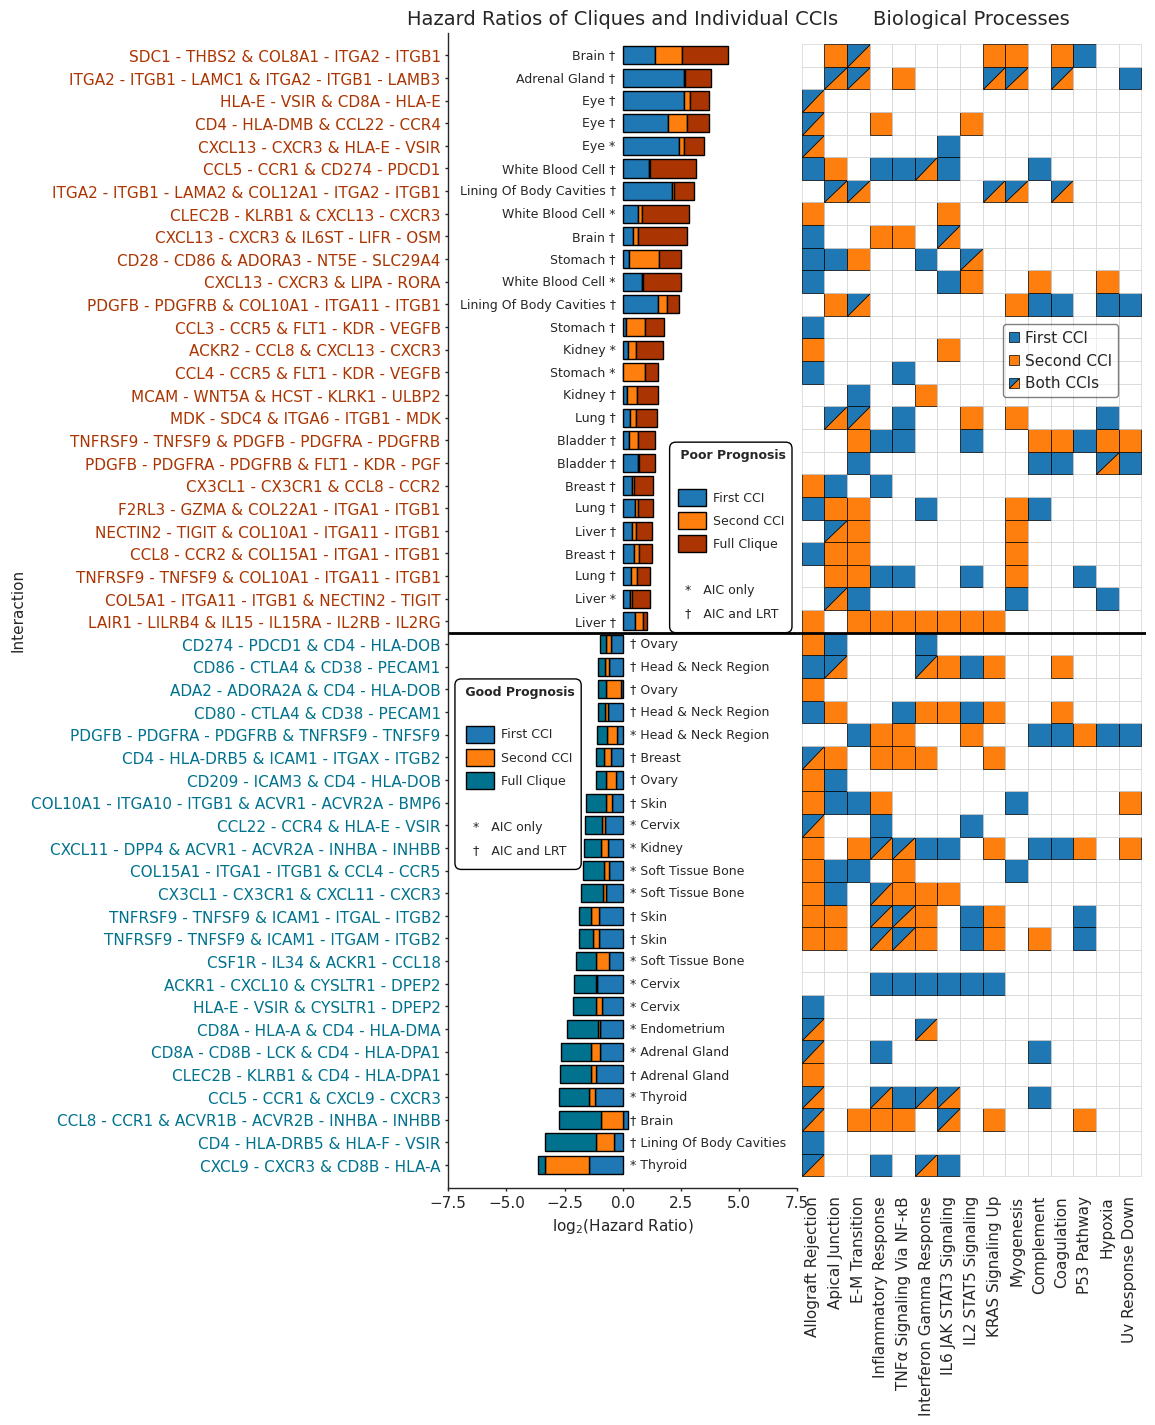

In [200]:
import matplotlib.patches as patches
import matplotlib.patches as mpatches

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import numpy as np
import matplotlib.colors as mcolors

titlefs=14
fs = 11
smallfs = 9
height = 0.8
N = 15  # number of hallmarks to select

CLUSTER = False  # Set to True if you want to cluster the heatmap

# Count how many interactions have each hallmark (non-zero values)
hallmark_counts = (heatmap_df != 0).sum(axis=0)
hallmark_counts_df = hallmark_counts.reset_index()
hallmark_counts_df.columns = ['hallmark', 'count']

top_hallmarks = (
    hallmark_counts_df
    .sort_values(by=['count', 'hallmark'], ascending=[False, True])
    .head(N)['hallmark']
)

## Select top N hallmarks by count
#top_hallmarks = hallmark_counts.sort_values(ascending=False).head(N).index

top_heatmap_df = heatmap_df[top_hallmarks]

# Optional: replace all non-zero values with 1 and cluster columns (processes)
if CLUSTER:
    binary_heatmap_df = top_heatmap_df.copy()
    binary_heatmap_df[binary_heatmap_df > 0] = 1
    # Cluster columns using scipy
    from scipy.cluster.hierarchy import linkage, leaves_list
    from scipy.spatial.distance import squareform
    from scipy.cluster.hierarchy import dendrogram
    # Compute linkage matrix
    Z = linkage(squareform(1 - binary_heatmap_df.corr()), method='average')
    # Get the order of columns based on clustering
    cluster_order = leaves_list(Z)
    # Reorder columns in top_heatmap_df
    top_heatmap_df = top_heatmap_df.iloc[:, cluster_order]

# Sort barplotdf by log2_hr ascending and get y positions
barplotdf = barplotdf.sort_values(by='log2_hr', ascending=True)
y_pos = np.arange(len(barplotdf))

# Use your top_heatmap_df from earlier (rows = interactions, cols = top hallmarks)
# Make sure it aligns with barplotdf index order
top_heatmap_df = top_heatmap_df.loc[barplotdf['interaction']]

# Prepare the matrix for imshow
hallmark_matrix = top_heatmap_df.values

# Define colors: white (0), blue (1), orange (2), purple (3)
#colors = ['white', 'C0', 'C1', 'purple']
#cmap = mcolors.ListedColormap(colors)
#bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
#norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Create figure and gridspec with adjusted width ratios
fig = plt.figure(figsize=(9, 15))  # Increased width overall for more room
gs = gridspec.GridSpec(1, 2, width_ratios=[1., 1], wspace=0)  # Give more room to heatmap
ax = fig.add_subplot(gs[0])
ax_hm = fig.add_subplot(gs[1])

# Plot barplot (same as your original code)
for j, (i, row) in enumerate(barplotdf.iterrows()):
    ypos = y_pos[j]
    hr1 = row['log2_hr1']
    hr2 = row['log2_hr2']
    hr = row['log2_hr']

    if hr1 != 0:
        ax.barh(ypos, hr1, color='C0', height=height, edgecolor='k', linewidth=1)

    if hr1 * hr2 < 0:
        left2 = 0
        width2 = hr2
    else:
        left2 = hr1
        width2 = hr2 - hr1
    ax.barh(ypos, width2, left=left2, color='C1', height=height, edgecolor='k', linewidth=1)

    width3 = hr - hr2
    color = tcolor if hr > 0 else ncolor
    if width3 != 0:
        ax.barh(ypos, width3, left=hr2, color=color, height=height, edgecolor='k', linewidth=1)

# Tissue labels
for j, row in enumerate(barplotdf.itertuples()):
    ypos = y_pos[j]
    tissue = row.tissue
    hr = row.log2_hr
    
    significance = ''
    if row.aic_lower:
        significance = '*'
    if row.aic_lower & row.lrt_significant:
        significance = '†'
    
    if hr >= 0:
        ax.text(-0.3, ypos, tissue+' '+significance, va='center', ha='right', fontsize=smallfs)
    else:
        ax.text(0.3, ypos, significance+' '+tissue, va='center', ha='left', fontsize=smallfs)

# Axis settings
ax.set_yticks(y_pos)
ax.set_yticklabels(barplotdf['interaction'], fontsize=fs)
ax.invert_yaxis()
ax.set_xlabel('log$_2$(Hazard Ratio)', fontsize=fs)
ax.set_ylabel('Interaction', fontsize=fs)
ax.set_ylim(-1, len(barplotdf))
ax.tick_params(axis='x', labelsize=fs)
ax.set_xlim(-7.5, 7.5)

N_neg = sum(barplotdf['log2_hr'] < 0)
ax.axhline(N_neg - 0.5, color='black', linewidth=2, linestyle='-')

y_labels = ax.get_yticklabels()
for i, label in enumerate(y_labels):
    label.set_color(ncolor if i < N_neg else tcolor)

# Remove spines
for spine in ax_hm.spines.values():
    spine.set_visible(False)

# Heatmap axis tweaks:
ax_hm.clear()
ax_hm.set_yticks([])  # Hide y ticks
ax_hm.tick_params(axis='x', which='both', bottom=True, top=False, length=2, width=1)
ax_hm.tick_params(axis='y', which='both', bottom=True, top=False, length=2, width=1)

# Major ticks centered
ax_hm.set_xticks(np.arange(len(top_heatmap_df.columns)) + 0.5)
ax_hm.set_xticklabels(top_heatmap_df.columns, rotation=90, fontsize=fs)

# Minor ticks on edges for grid
ax_hm.set_xticks(np.arange(len(top_heatmap_df.columns)+1), minor=True)
ax_hm.set_yticks(np.arange(hallmark_matrix.shape[0]+1)-0.5, minor=True)

ax_hm.grid(which='minor', color='white', linewidth=2.5)
ax_hm.tick_params(which='minor', bottom=False, left=False, length=2, width=1)

# Draw squares and triangles
cell_height = 1
cell_width = 1
for row_idx in range(hallmark_matrix.shape[0]):
    for col_idx in range(hallmark_matrix.shape[1]):
        val = hallmark_matrix[row_idx, col_idx]
        y = row_idx
        x = col_idx

        if val == 0:
            rect = patches.Rectangle((x, y), cell_width, cell_height, facecolor='white', edgecolor='lightgray', linewidth=0.5)
            ax_hm.add_patch(rect)
        elif val == 1:
            rect = patches.Rectangle((x, y), cell_width, cell_height, facecolor='C0', edgecolor='k', linewidth=0.5)
            ax_hm.add_patch(rect)
        elif val == 2:
            rect = patches.Rectangle((x, y), cell_width, cell_height, facecolor='C1', edgecolor='k', linewidth=0.5)
            ax_hm.add_patch(rect)
        elif val == 3:
            xy = [(x, y), (x + cell_width, y), (x + cell_width, y + cell_height), (x, y + cell_height)]
            tri1 = patches.Polygon([xy[0], xy[3], xy[2]], facecolor='C0', edgecolor='k', linewidth=0.5)
            tri2 = patches.Polygon([xy[0], xy[1], xy[2]], facecolor='C1', edgecolor='k', linewidth=0.5)
            ax_hm.add_patch(tri1)
            ax_hm.add_patch(tri2)

ax_hm.set_xlim(0, hallmark_matrix.shape[1])
ax_hm.set_ylim(-0.5, hallmark_matrix.shape[0]+0.5)

# **Make cells square and prevent cropping**
ax_hm.set_aspect('equal', adjustable='datalim')  # Make squares

# Labels
props = dict(boxstyle='round,pad=0.5', facecolor='none', edgecolor='black', linewidth=1)

leg_y_poor = 0.64
ax.text(0.81, leg_y_poor, ' Poor Prognosis' + 11*'\n', ha='center', va='top', fontsize=smallfs, transform=ax.transAxes, bbox=props, weight='bold')
leg_y_good = 0.435
ax.text(0.20, leg_y_good, ' Good Prognosis' + 11*'\n', ha='center', va='top', fontsize=smallfs, transform=ax.transAxes, bbox=props, weight='bold')
leg_y_offset = 0.05

# Legend for high expression box
legend_x, legend_y = 0.66, leg_y_poor - leg_y_offset
width, height = 0.08, 0.015
ax.add_patch(patches.Rectangle((legend_x, legend_y), width, height, transform=ax.transAxes,
                               facecolor='C0', edgecolor='k'))
ax.text(legend_x + width + 0.02, legend_y + height/2, 'First CCI', transform=ax.transAxes,
        va='center', fontsize=smallfs)

legend_y -= 0.02
ax.add_patch(patches.Rectangle((legend_x, legend_y), width, height, transform=ax.transAxes,
                               facecolor='C1', edgecolor='k'))
ax.text(legend_x + width + 0.02, legend_y + height/2, 'Second CCI', transform=ax.transAxes,
        va='center', fontsize=smallfs)

legend_y -= 0.02
color = tcolor  # or ncolor if you want to differentiate
ax.add_patch(patches.Rectangle((legend_x, legend_y), width, height, transform=ax.transAxes,
                               facecolor=color, edgecolor='k'))
ax.text(legend_x + width + 0.02, legend_y + height/2, 'Full Clique', transform=ax.transAxes,
        va='center', fontsize=smallfs)

legend_y -= 0.04
ax.text(legend_x + 0.02, legend_y + height/2, '*   AIC only', transform=ax.transAxes,
        va='center', fontsize=smallfs)

legend_y -= 0.02
ax.text(legend_x + 0.02, legend_y + height/2, '†   AIC and LRT', transform=ax.transAxes,
        va='center', fontsize=smallfs)

# Legend for low expression box
legend_x, legend_y = 0.05, leg_y_good - leg_y_offset
width, height = 0.08, 0.015
ax.add_patch(patches.Rectangle((legend_x, legend_y), width, height, transform=ax.transAxes,
                               facecolor='C0', edgecolor='k'))
ax.text(legend_x + width + 0.02, legend_y + height/2, 'First CCI', transform=ax.transAxes,
        va='center', fontsize=smallfs)

legend_y -= 0.02
ax.add_patch(patches.Rectangle((legend_x, legend_y), width, height, transform=ax.transAxes,
                               facecolor='C1', edgecolor='k'))
ax.text(legend_x + width + 0.02, legend_y + height/2, 'Second CCI', transform=ax.transAxes,
        va='center', fontsize=smallfs)

legend_y -= 0.02
ax.add_patch(patches.Rectangle((legend_x, legend_y), width, height, transform=ax.transAxes,
                               facecolor=ncolor, edgecolor='k'))
ax.text(legend_x + width + 0.02, legend_y + height/2, 'Full Clique', transform=ax.transAxes,
        va='center', fontsize=smallfs)

legend_y -= 0.04
ax.text(legend_x + 0.02, legend_y + height/2, '*   AIC only', transform=ax.transAxes,
        va='center', fontsize=smallfs)

legend_y -= 0.02
ax.text(legend_x + 0.02, legend_y + height/2, '†   AIC and LRT', transform=ax.transAxes,
        va='center', fontsize=smallfs)

# Legend for biological processes
class HandlerSplitSquare(HandlerBase):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        tri1 = patches.Polygon([[xdescent, ydescent],
                                [xdescent, ydescent + height],
                                [xdescent + width, ydescent + height]],
                               facecolor='C0', edgecolor='k', linewidth=0.5, transform=trans)
        tri2 = patches.Polygon([[xdescent, ydescent],
                                [xdescent + width, ydescent],
                                [xdescent + width, ydescent + height]],
                               facecolor='C1', edgecolor='k', linewidth=0.5, transform=trans)
        return [tri1, tri2]

patch_c0 = patches.Rectangle((0, 0), 1, 1, facecolor='C0', edgecolor='k', linewidth=0.5)
patch_c1 = patches.Rectangle((0, 0), 1, 1, facecolor='C1', edgecolor='k', linewidth=0.5)
split_square_handle = object()

ax_hm.legend(
    handles=[patch_c0, patch_c1, split_square_handle],
    labels=['First CCI', 'Second CCI', 'Both CCIs'],
    handler_map={split_square_handle: HandlerSplitSquare()},
    loc='lower center',
    bbox_to_anchor=(0.755, 0.678),
    fontsize=fs,
    ncol=1,
    frameon=True,
    facecolor='white',
    framealpha=0.5,
    edgecolor='black',
    handlelength=0.65,
    handleheight=0.65,
    handletextpad=0.4,
)

# Add horizontal line to heatmap matching the barplot
ax_hm.axhline(N_neg, color='black', linewidth=2, linestyle='-')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_title('Hazard Ratios of Cliques and Individual CCIs', fontsize=titlefs)
ax_hm.set_title('Biological Processes', fontsize=titlefs)

ax.tick_params(bottom=True, top=False, left=True, labelbottom=True, length=2, width=1)
ax_hm.tick_params(bottom=False, top=False, left=False, labelbottom=True, length=2, width=1)

#plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/survival_hr_barplot.pdf', bbox_inches='tight', dpi=300)
#plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/survival_hr_barplot.png', bbox_inches='tight', dpi=300)

plt.show()

In [201]:
# SAVE CROSSTALKDF WITH HALLAMRKS

dataframe = better.copy()

import re

# Split interactions into individual genes for each side
dataframe['interaction1'] = dataframe.interaction.apply(lambda x: re.split('&', x)[0].strip())
dataframe['interaction1'] = dataframe['interaction1'].apply(lambda x: re.split(r'[+_]', x))
dataframe['interaction2'] = dataframe.interaction.apply(lambda x: re.split('&', x)[1].strip())
dataframe['interaction2'] = dataframe['interaction2'].apply(lambda x: re.split(r'[+_]', x))

# Load hallmark gene sets
def read_gmt(file_path):
    gene_sets = {}
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 3:
                gene_sets[parts[0]] = set(parts[2:])
    return gene_sets

hallmarks_path = '/home/lnemati/resources/msigdb_hallmarks/h.all.v2024.1.Hs.symbols.gmt'
hallmarks = read_gmt(hallmarks_path)

# Function to find matching hallmark sets for a given gene list
def find_matching_hallmarks(gene_list, hallmark_sets):
    return [name for name, genes in hallmark_sets.items() if set(gene_list) & genes]

# Get hallmarks for each side of the interaction
dataframe['hallmarks1'] = dataframe['interaction1'].apply(lambda genes: find_matching_hallmarks(genes, hallmarks))
dataframe['hallmarks2'] = dataframe['interaction2'].apply(lambda genes: find_matching_hallmarks(genes, hallmarks))

# Convert to readable labels using the name map
#dataframe['hallmarks1'] = dataframe['hallmarks1'].apply(lambda hlist: [hallmark_name_map[h] for h in hlist])
#dataframe['hallmarks2'] = dataframe['hallmarks2'].apply(lambda hlist: [hallmark_name_map[h] for h in hlist])

dataframe = dataframe.query('tissue != "Pan_Cancer" and motif in ["3_clique", "4_clique"]')

#dataframe.to_csv('/home/lnemati/pathway_crosstalk/results/survival/cliques_better_with_processes.csv')


# Define subset of hallmarks you want to consider (for example, top N or all unique found)
# For demonstration, use all unique hallmarks found across both sides:
all_hallmarks = sorted(set(sum(dataframe['hallmarks1'], [])) | set(sum(dataframe['hallmarks2'], [])))

# Initialize matrix: rows = interactions, columns = hallmarks
#heatmap_matrix = np.zeros((len(barplotdf), len(all_hallmarks)), dtype=int)

# Fill matrix with presence codes
#for i, row in enumerate(barplotdf.itertuples(index=False)):
#    hallmarks_1 = set(row.hallmarks1)
#    hallmarks_2 = set(row.hallmarks2)
#    for j, hallmark in enumerate(all_hallmarks):
#        in_1 = hallmark in hallmarks_1
#        in_2 = hallmark in hallmarks_2
#        heatmap_matrix[i, j] = 1 * in_1 + 2 * in_2  # 0, 1, 2, or 3
#
#heatmap_df = pd.DataFrame(heatmap_matrix, index=barplotdf.interaction, columns=all_hallmarks)    
#heatmap_df = heatmap_df[::-1] # Invert to match order of the plot

In [202]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact

# Initialize storage for hallmark analysis
bad_counts = []
good_counts = []
log_odds_ratios = []
p_values = []

# Total number of bad and good prognosis cases
bad_total = dataframe.query('hr > 1').shape[0]
good_total = dataframe.query('hr < 1').shape[0]

# Loop through each hallmark
for hm in all_hallmarks:
    # a: hallmark in poor prognosis
    a = dataframe.query('hr > 1').apply(lambda x: hm in x.hallmarks1 or hm in x.hallmarks2, axis=1).sum()
    b = bad_total - a  # hallmark not in poor prognosis

    # c: hallmark in good prognosis
    c = dataframe.query('hr < 1').apply(lambda x: hm in x.hallmarks1 or hm in x.hallmarks2, axis=1).sum()
    d = good_total - c  # hallmark not in good prognosis

    # Store counts
    bad_counts.append(a)
    good_counts.append(c)

    # Fisher's exact test
    table = [[a, b], [c, d]]
    oddsratio, pvalue = fisher_exact(table)
    log_or = np.log2(oddsratio) if oddsratio > 0 else np.nan

    # Store test results
    log_odds_ratios.append(log_or)
    p_values.append(pvalue)

# Create the DataFrame
hallmark_summary = pd.DataFrame({
    'hallmark': all_hallmarks,
    'bad_prognosis_count': bad_counts,
    'good_prognosis_count': good_counts,
    'log_odds_ratio': log_odds_ratios,
    'p_value': p_values
})

# Also get probabilities not just counts
hallmark_summary['bad_prognosis_prob'] = hallmark_summary['bad_prognosis_count'] / bad_total
hallmark_summary['good_prognosis_prob'] = hallmark_summary['good_prognosis_count'] / good_total

# Optional: sort by significance or effect size
hallmark_summary = hallmark_summary.sort_values('p_value')

# Save the summary DataFrame
#hallmark_summary.to_csv('/home/lnemati/pathway_crosstalk/results/survival/hallmarks_survival.csv', index=False)

# Multiple hypothesis testing
hallmark_summary['pval_adj'] = false_discovery_control(hallmark_summary['p_value'])

hallmark_summary['hallmark'] = hallmark_summary['hallmark'].str.replace('HALLMARK_', '').str.replace('_', ' ').str.title()

for str1, str2 in replace.items():
    hallmark_summary['hallmark'] = hallmark_summary['hallmark'].str.replace(str1, str2)

#good_df = hallmark_summary.query('log_odds_ratio < 0').sort_values(by='good_prognosis_prob', ascending=False)
#bad_df = hallmark_summary.query('log_odds_ratio > 0').sort_values(by='bad_prognosis_prob', ascending=False)

good_df = hallmark_summary.query('pval_adj < 0.05 and log_odds_ratio < 0').sort_values(by='good_prognosis_prob', ascending=False)
bad_df = hallmark_summary.query('pval_adj < 0.05 and log_odds_ratio > 0').sort_values(by='bad_prognosis_prob', ascending=False)

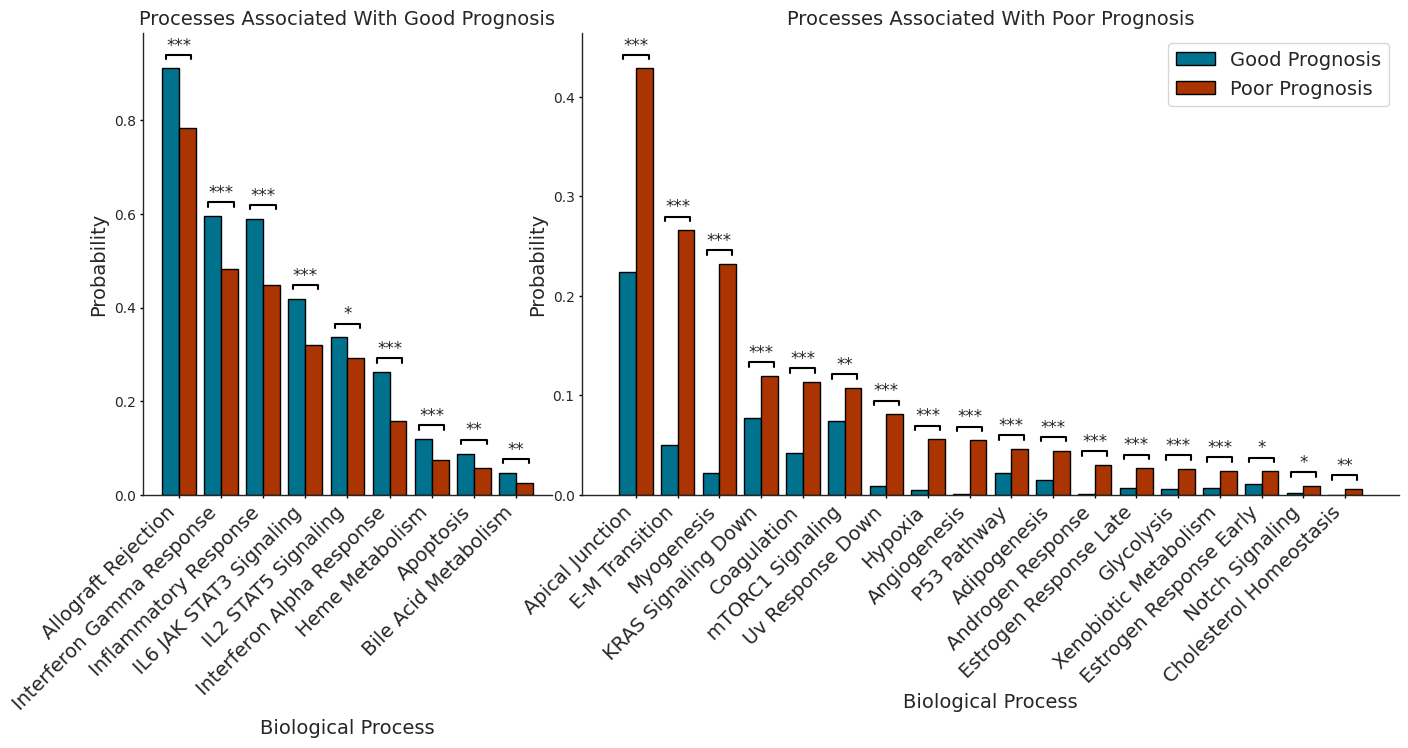

In [203]:
import matplotlib.pyplot as plt
import numpy as np

# Constants
per_bar_width = 0.6  # width in inches per bar, tweak as needed
height = 6           # fixed figure height
fs = 14
smallfs = 11

# Function to plot one panel with vertical bars
def plot_panel(df, ax, title, color1, color2,):
    hallmarks = df['hallmark']
    x_pos = np.arange(len(df))

    ax.bar(x_pos - 0.2, df['good_prognosis_prob'], width=0.4, color=color1, edgecolor='black', label='Good Prognosis')
    ax.bar(x_pos + 0.2, df['bad_prognosis_prob'], width=0.4, color=color2, edgecolor='black', label='Poor Prognosis')

    for i, row in df.iterrows():
        total_height = ax.get_ylim()[1] - ax.get_ylim()[0]
        x = x_pos[df.index.get_loc(i)]
        pval = row['pval_adj']
        stars = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
        if stars:
            max_prob = max(row['good_prognosis_prob'], row['bad_prognosis_prob'])
            ypos = max_prob + 0.02 * total_height
            h = 0.01 * total_height
            w = 0.3
            ax.plot([x - w, x - w, x + w, x + w], [ypos, ypos + h, ypos + h, ypos], color='black', linewidth=1.5)
            ax.text(x, max_prob + 4*h, stars, ha='center', fontsize=12)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(hallmarks, rotation=45, ha='right', fontsize=fs)
    ax.set_ylabel('Probability', fontsize=fs)
    ax.set_xlabel('Biological Process', fontsize=fs)
    ax.set_title(title, fontsize=fs)

    # Imposta che i tick siano mostrati
    ax.tick_params(
        axis='both',
        which='both',
        direction='out',
        length=2,
        width=1,
        color='black'
    )
    ax.xaxis.set_ticks_position('bottom')  # obbliga i tick sull’asse x
    ax.yaxis.set_ticks_position('left')    # obbliga i tick sull’asse y

    # Hide top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add legend
    ax.legend(fontsize=fs, loc='upper right')

# Calculate subplot widths
good_width = max(len(good_df) * per_bar_width, 2)  # min width 2 inches for readability
bad_width = max(len(bad_df) * per_bar_width, 2)

total_width = good_width + bad_width

fig, (ax1, ax2) = plt.subplots(
    ncols=2,
    figsize=(total_width, height),
    gridspec_kw={'width_ratios': [good_width, bad_width]},
    sharey=False
)

plt.subplots_adjust(wspace=0.05)

# Plot both panels
plot_panel(good_df, ax1, 'Processes Associated With Good Prognosis', ncolor, tcolor)
plot_panel(bad_df, ax2, 'Processes Associated With Poor Prognosis', ncolor, tcolor)

# Remove legend from ax1
ax1.legend_.remove()

# Save the figure
#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/survival/hallmarks_prognosis_all.pdf', bbox_inches='tight', dpi=300)
#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/survival/hallmarks_prognosis_all.png', bbox_inches='tight', dpi=300)

plt.show()


In [204]:
PLOT = False

if PLOT:
    for tissue in to_plot['tissue'].unique():
        print(tissue)
        survival_df = pd.read_csv('/home/lnemati/pathway_crosstalk/data/survival_data/tissues/' + tissue.lower().replace(' ', '_') + '.csv', index_col=0)
        for interactions in to_plot.query('tissue == @tissue')['interaction']:
            print(interactions)
            # Uncropped
            outdir =  os.path.join('/home/lnemati/pathway_crosstalk/results/survival/plots/', 'uncropped', tissue)
            os.makedirs(outdir, exist_ok=True)
            #plot_all_3(interactions, tissue, survival_df, xlim=(0, 15), ylim=(0., 1.01), show=False, savepath=os.path.join(outdir, interactions))
            plot_all_3(interactions, tissue, survival_df, xlim=(0, 15), ylim=(0., 1.01), show=True)#, savepath=os.path.join(outdir, interactions))

            ## Cropped
            #outdir =  os.path.join('/home/lnemati/pathway_crosstalk/results/survival/plots/', 'cropped', tissue)
            #os.makedirs(outdir, exist_ok=True)
            #plot_all_3(interactions, tissue, survival_df, xlim=(0, 15), ylim=(0.5, 1.005), show=False, savepath=os.path.join(outdir, interactions)+'_crop1')
            #plot_all_3(interactions, tissue, survival_df, xlim=(0, 10), ylim=(0.5, 1.005), show=False, savepath=os.path.join(outdir, interactions)+'_crop2')
            #plot_all_3(interactions, tissue, survival_df, xlim=(0, 5 ), ylim=(0.5, 1.005), show=False, savepath=os.path.join(outdir, interactions)+'_crop3')

            print('------------------------------------------')
            print()
            print()
            print()
            print()
            print()
            print()

    # uncropped 0 15
    # crop1 0.5 15
    # crop2 0.5 10
    # crop3 0.5 5

# FULL FIGURE

In [205]:
import matplotlib.pyplot as plt
import numpy as np

# BARPLOT: Function to plot one panel with vertical bars
def plot_panel(df, ax, title, good_color, bad_color,fs=14, smallfs=11):
    hallmarks = df['hallmark']
    x_pos = np.arange(len(df))

    # Constants
    per_bar_width = 0.6  # width in inches per bar, tweak as needed
    height = 6           # fixed figure height

    ax.bar(x_pos - 0.2, df['good_prognosis_prob'], width=0.4, color=good_color, edgecolor='black', label='Good Prognosis')
    ax.bar(x_pos + 0.2, df['bad_prognosis_prob'], width=0.4, color=bad_color, edgecolor='black', label='Poor Prognosis')

    for i, row in df.iterrows():
        total_height = ax.get_ylim()[1] - ax.get_ylim()[0]
        x = x_pos[df.index.get_loc(i)]
        pval = row['pval_adj']
        stars = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
        if stars:
            max_prob = max(row['good_prognosis_prob'], row['bad_prognosis_prob'])
            ypos = max_prob + 0.02 * total_height
            h = 0.01 * total_height
            w = 0.3
            ax.plot([x - w, x - w, x + w, x + w], [ypos, ypos + h, ypos + h, ypos], color='black', linewidth=1.5)
            ax.text(x, max_prob + 4*h, stars, ha='center', fontsize=fs)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(hallmarks, rotation=45, ha='right', fontsize=fs)
    ax.set_ylabel('Probability', fontsize=fs)
    ax.set_xlabel('Biological Process', fontsize=fs)
    ax.set_title(title, fontsize=fs)

    ax.tick_params(
        axis='both',
        which='both',
        direction='out',
        length=2,
        width=1,
        color='black',
        labelsize=smallfs
    )
    ax.xaxis.set_ticks_position('bottom')  # obbliga i tick sull’asse x
    ax.yaxis.set_ticks_position('left')    # obbliga i tick sull’asse y

    # Hide top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add legend
    ax.legend(fontsize=fs, loc='upper right')

    return

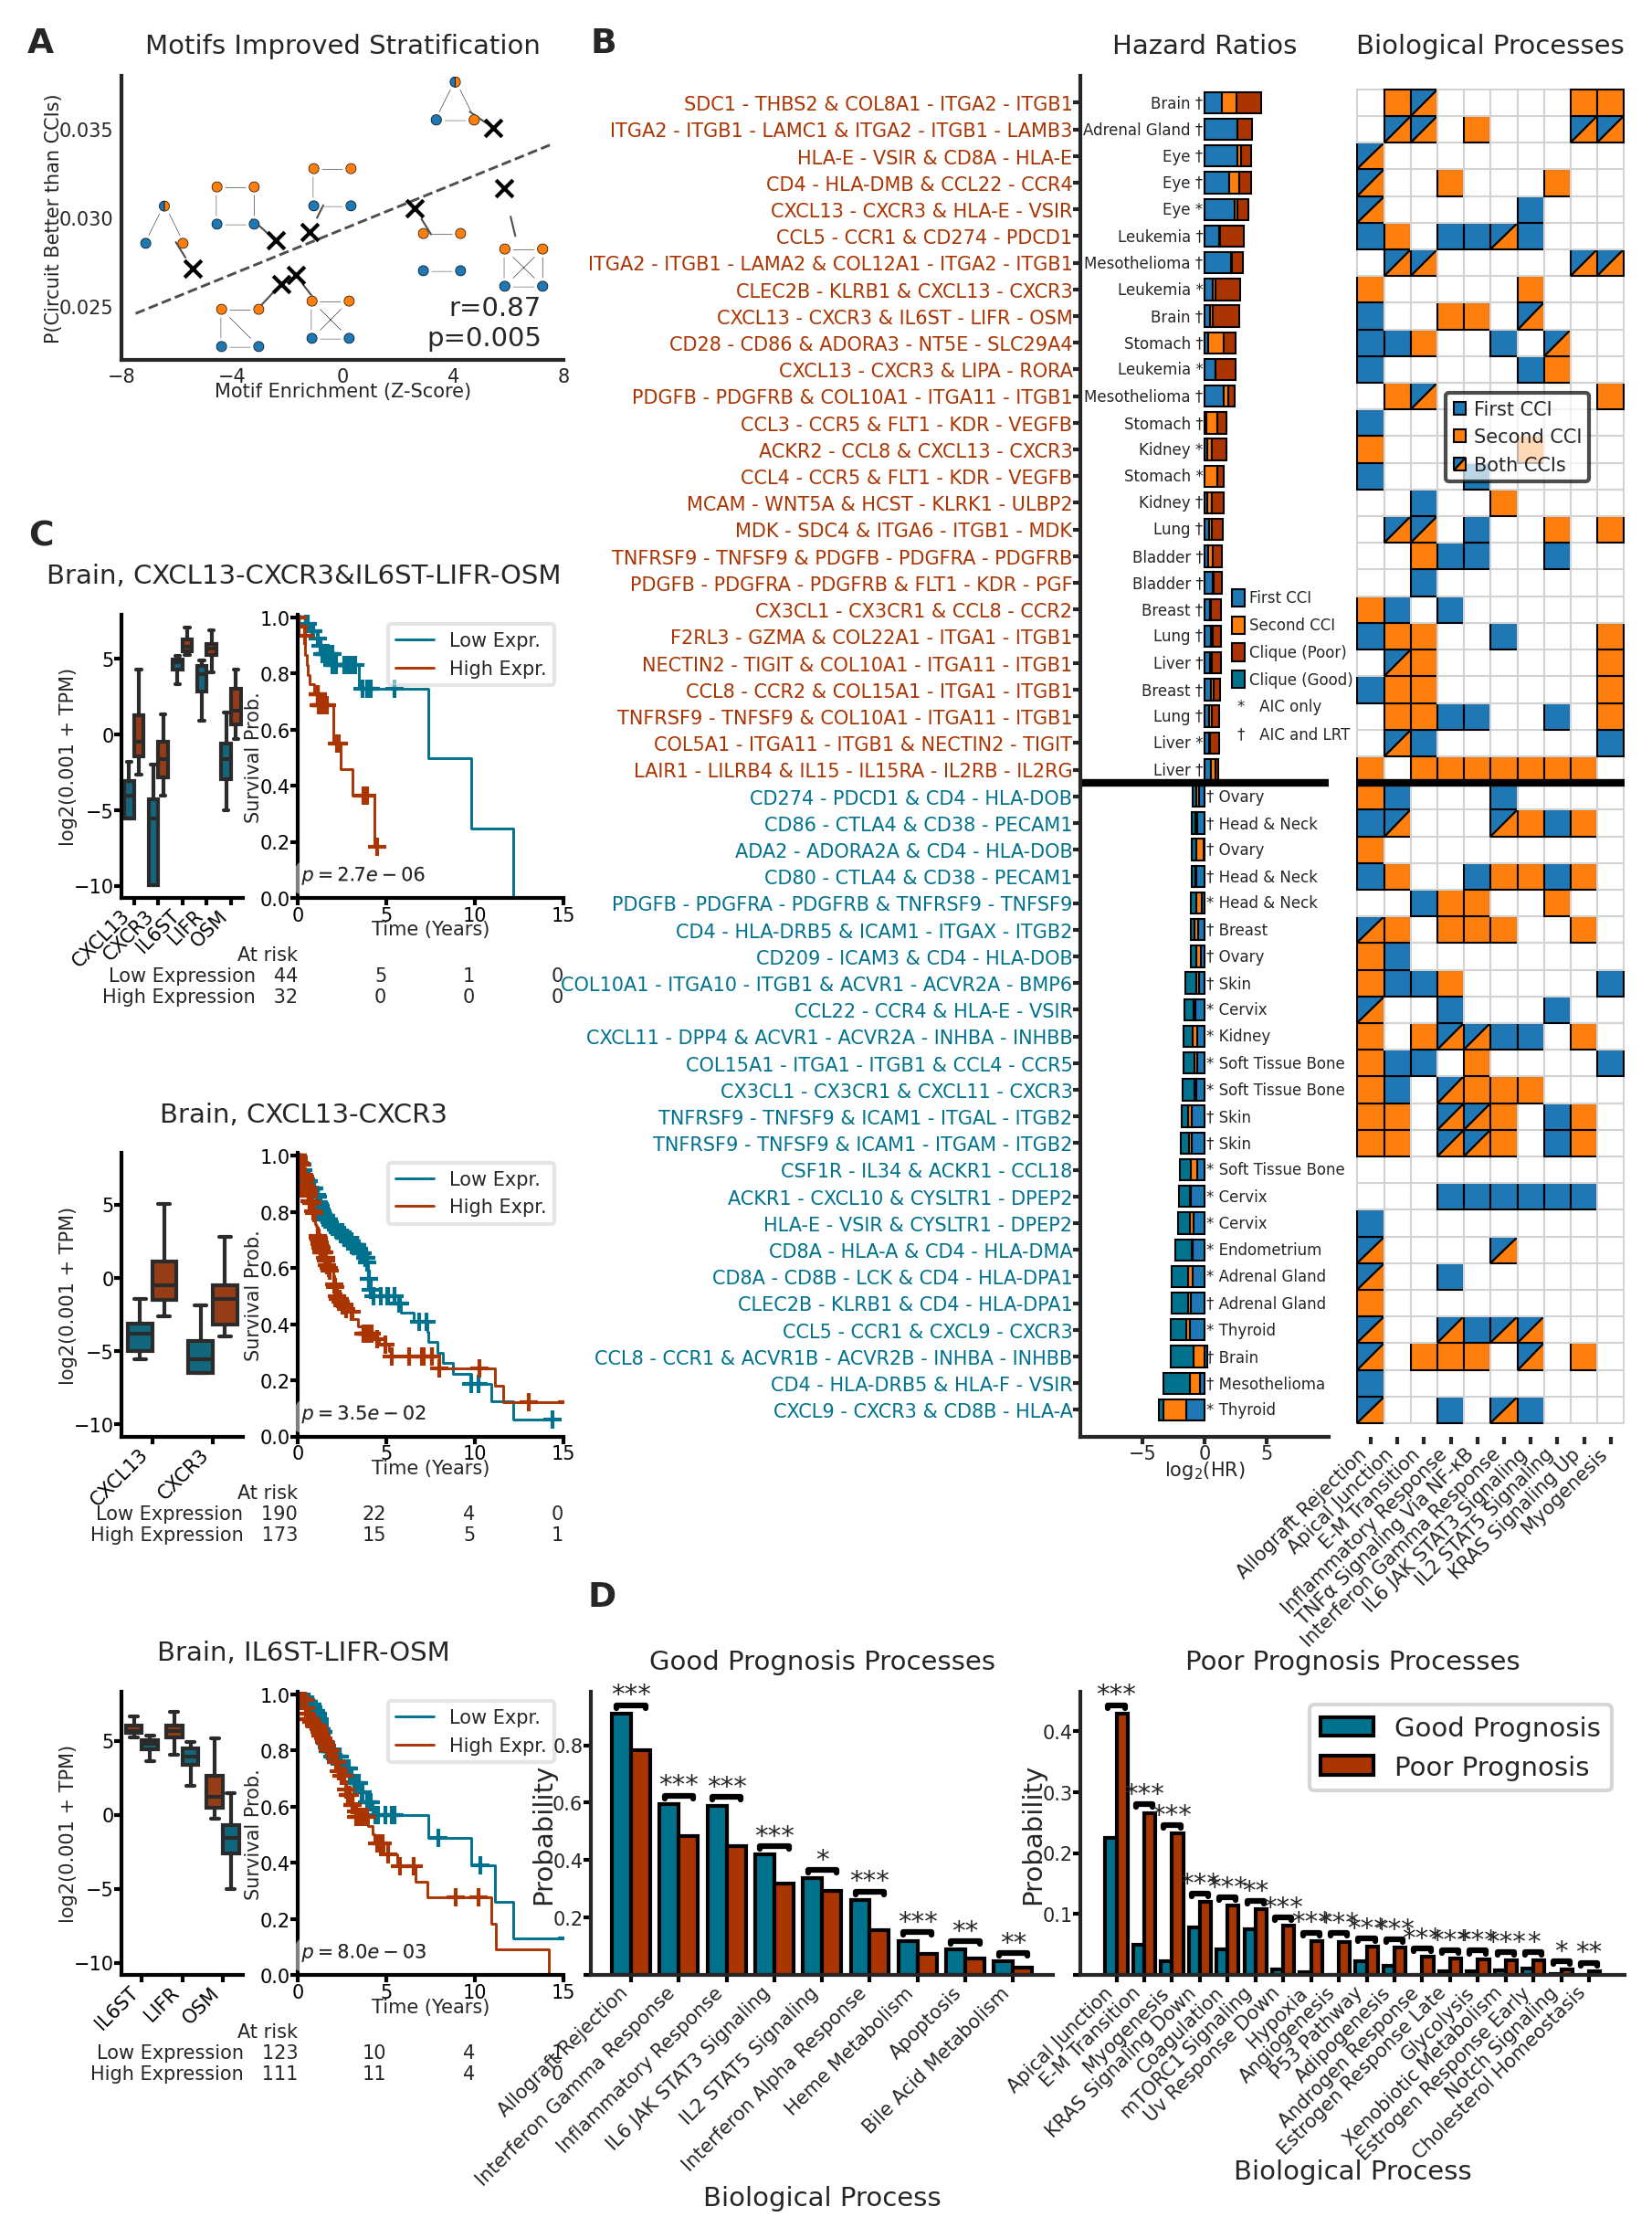

In [260]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from PIL import Image
import os
from scipy.stats import pearsonr, spearmanr
import numpy as np

fs = 7
smallfs = 5
height = 0.8
N = 10  # number of hallmarks to select

# Example: Replace with your actual data
# barplotdf, heatmap_df should be defined before this point

# Count how many interactions have each hallmark (non-zero values)
hallmark_counts = (heatmap_df != 0).sum(axis=0)
hallmark_counts_df = hallmark_counts.reset_index()
hallmark_counts_df.columns = ['hallmark', 'count']

top_hallmarks = (
    hallmark_counts_df
    .sort_values(by=['count', 'hallmark'], ascending=[False, True])
    .head(N)['hallmark']
)

#top_hallmarks = hallmark_counts.sort_values(ascending=False).head(N).index

top_heatmap_df = heatmap_df[top_hallmarks]

barplotdf = barplotdf.sort_values(by='log2_hr', ascending=True)
y_pos = np.arange(len(barplotdf))
top_heatmap_df = top_heatmap_df.loc[barplotdf['interaction']]
hallmark_matrix = top_heatmap_df.values

fig, axs = plt.subplot_mosaic(
    """
    CCCXBb
    ixIXBb
    jxJXBb
    kxKDEE
    """,
    dpi=300,
    figsize=(7.08, 9),
    gridspec_kw={
        "width_ratios": [0.21, 0.0001, 0.46, 0.8, 0.43, 0.465]
    }
)

fig.subplots_adjust(hspace=0.9, wspace=0.12)

###################### PANEL X: empty space
if 'X' in axs:
    axs['X'].axis('off')
if 'x' in axs:
    axs['x'].axis('off')


####################### PANELS I, J, K: Survival

tissue = 'Brain'
interactions = 'CXCL13+CXCR3&IL6ST_LIFR+OSM'
    
survival_df = pd.read_csv('/home/lnemati/pathway_crosstalk/data/survival_data/tissues/' + tissue.lower().replace(' ', '_') + '.csv', index_col=0)

surv_axes = [
    (axs['i'], axs['I']),
    (axs['j'], axs['J']),
    (axs['k'], axs['K']),
]

plot_all_3(interactions, tissue, survival_df, surv_axes, fs=fs, smallfs=smallfs)

for ax in 'iIjJkK':
    axs[ax].set_title('')
    
x = 1.5
y = 1.03

axs['i'].set_title('Brain, CXCL13-CXCR3&IL6ST-LIFR-OSM', ha='center', fontsize=fs, x=x, y=y)
axs['I'].set_title('', fontsize=fs)
axs['j'].set_title('Brain, CXCL13-CXCR3', ha='center', fontsize=fs, x=x, y=y)
axs['J'].set_title('', fontsize=fs)
axs['k'].set_title('Brain, IL6ST-LIFR-OSM', ha='center', fontsize=fs, x=x, y=y)
axs['K'].set_title('', fontsize=fs)

# CXCL13+CXCR3&IL6ST_LIFR+OSM

###################### PANEL A: Correlation ##############

ax = axs['C']

# --- Constants ---
dpi = 300
img_dir = '/home/lnemati/pathway_crosstalk/data/motifs_icons/'
image_scaling_factor = 0.18  # smaller for subplot usage

x_offset = -1
y_offset = 0.0025

# --- Filter Data ---
df = better.query('tissue != "Pan_Cancer"')
all_counts = crosstalkdf.query('tissue != "Pan_Cancer"').motif.value_counts().sort_values(ascending=False)
probs = (df.motif.value_counts() / all_counts).sort_values()
probs = probs.loc[motifs_z.index]

data = pd.DataFrame({'z': motifs_z, 'prob': probs})

# Correlation
r_value, p_r_value = pearsonr(probs, motifs_z)
rho_value, p_rho_value = spearmanr(probs, motifs_z)

# Plot

# Scatter
ax.scatter(data['z'], data['prob'], color='black', marker='x', s=20, linewidths=1.)

# Correlation text
ax.text(0.95, 0.05, f'r={r_value:.2f}\np={p_r_value:.3f}',
        transform=ax.transAxes, fontsize=fs, ha='right')

# Axes settings
ax.set_xlim(-8, 8)
ax.set_ylim(0.022, 0.038)
ax.set_xticks([-8, -4, 0, 4, 8])
ax.set_yticks([0.025, 0.030, 0.035])
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(labelsize=smallfs, length=2, width=1)
ax.set_title('Motifs Improved Stratification', fontsize=fs)
ax.set_xlabel('Motif Enrichment (Z-Score)', fontsize=smallfs)
ax.set_ylabel('P(Circuit Better than CCIs)', fontsize=smallfs)

# Regression line
slope, intercept = np.polyfit(data['z'], data['prob'], 1)
x_extended = np.linspace(ax.get_xlim()[0] + 0.5, ax.get_xlim()[1] - 0.5, 100)
y_extended = slope * x_extended + intercept
ax.plot(x_extended, y_extended, linestyle='--', color=graycolor, linewidth=0.7, zorder=-10)

motif_positions = {
    '3_path': (data['z']['3_path'], data['prob']['3_path']),
    '4_cycle': (data['z']['4_cycle'] - 0.45, data['prob']['4_cycle'] - 0.0005),
    '4_triangle_extra': (data['z']['4_triangle_extra']-0.5, data['prob']['4_triangle_extra'] - 0.005),
    '4_one_missing': (data['z']['4_one_missing'] + 2.25, data['prob']['4_one_missing'] - 0.005),
    '4_path': (data['z']['4_path'] + 1.8, data['prob']['4_path']),
    '4_no_crosstalk': (data['z']['4_no_crosstalk'] + 2, data['prob']['4_no_crosstalk'] - 0.005),
    '3_clique': (data['z']['3_clique'] - 0.4, data['prob']['3_clique'] - 0.001),
    '4_clique': (data['z']['4_clique'] + 1.7, data['prob']['4_clique'] - 0.007),
}

#motif_positions = {k: (data['z'][k], data['prob'][k]) for k in data.index}

# Add motif icons using inset_axes
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

for motif, (x_pos, y_pos) in motif_positions.items():
    img_path = os.path.join(img_dir, f"{motif}.png")
    x_pos += x_offset
    y_pos += y_offset
    if os.path.exists(img_path):
        # Convert data coordinates to axis-relative
        inv = ax.transData.transform
        trans = ax.transAxes.inverted().transform
        ax_rel_coords = trans(inv((x_pos, y_pos)))

        # Create inset axes at that location
        ax_img = inset_axes(ax,
                            width=image_scaling_factor,
                            height=image_scaling_factor,
                            loc='center',
                            bbox_to_anchor=(ax_rel_coords[0], ax_rel_coords[1]),
                            bbox_transform=ax.transAxes,
                            borderpad=0)

        # Load and show image
        im = Image.open(img_path)
        ax_img.imshow(im)
        ax_img.axis('off')

        # Line from data point to image center
        x0, y0 = data['z'][motif], data['prob'][motif]  # data point
        x1, y1 = x_pos, y_pos  # image anchor
        dx, dy = x1 - x0, y1 - y0
        length = np.hypot(dx, dy)
        line_frac = 0.4
        marker_trim = 0.25
        dxn, dyn = dx / length, dy / length
        x_start, y_start = x0 + dxn * marker_trim, y0 + dyn * marker_trim
        x_end, y_end = x1 - dxn * (line_frac * length), y1 - dyn * (line_frac * length)
        ax.plot([x_start, x_end], [y_start, y_end], color=graycolor, linewidth=0.5, zorder=-5)

# Legend (optional, usually omitted for clarity)
# ax.legend(fontsize=fs, loc='upper left')


######################### PANEL B: Barplot ####################

ax = axs['B']

# Count how many interactions have each hallmark (non-zero values)
hallmark_counts = (heatmap_df != 0).sum(axis=0)
hallmark_counts_df = hallmark_counts.reset_index()
hallmark_counts_df.columns = ['hallmark', 'count']

top_hallmarks = (
    hallmark_counts_df
    .sort_values(by=['count', 'hallmark'], ascending=[False, True])
    .head(N)['hallmark']
)

# Select top N hallmarks by count
#top_hallmarks = hallmark_counts.sort_values(ascending=False).head(N).index

top_heatmap_df = heatmap_df[top_hallmarks]

# Sort barplotdf by log2_hr ascending and get y positions
barplotdf = barplotdf.sort_values(by='log2_hr', ascending=True)
y_pos = np.arange(len(barplotdf))

# Use your top_heatmap_df from earlier (rows = interactions, cols = top hallmarks)
# Make sure it aligns with barplotdf index order
top_heatmap_df = top_heatmap_df.loc[barplotdf['interaction']]

# Prepare the matrix for imshow
hallmark_matrix = top_heatmap_df.values

for j, (i, row) in enumerate(barplotdf.iterrows()):
    ypos = y_pos[j]
    hr1 = row['log2_hr1']
    hr2 = row['log2_hr2']
    hr = row['log2_hr']

    if hr1 != 0:
        ax.barh(ypos, hr1, color='C0', height=height, edgecolor='k', linewidth=0.5)

    if hr1 * hr2 < 0:
        left2 = 0
        width2 = hr2
    else:
        left2 = hr1
        width2 = hr2 - hr1
    ax.barh(ypos, width2, left=left2, color='C1', height=height, edgecolor='k', linewidth=0.5)

    width3 = hr - hr2
    color = tcolor if hr > 0 else ncolor
    if width3 != 0:
        ax.barh(ypos, width3, left=hr2, color=color, height=height, edgecolor='k', linewidth=0.5)

    
replace = {
    'Head & Neck Region': 'Head & Neck',
    'Lining Of Body Cavities': 'Mesothelioma',
    'White Blood Cell': 'Leukemia',
}
        
# Tissue labels
for j, row in enumerate(barplotdf.itertuples()):
    hr = row.log2_hr
    ypos = y_pos[j]
    tissue = row.tissue
    tissue_label = replace.get(tissue, tissue)
    
    if row.aic_lower:
        significance = '*'
    if row.aic_lower & row.lrt_significant:
        significance = '†'
        
    if hr >= 0:
        ax.text(-0.12, ypos, tissue_label + ' ' + significance, va='center', ha='right', fontsize=smallfs-1)
    else:
        ax.text(0.12, ypos, significance + ' ' + tissue_label, va='center', ha='left', fontsize=smallfs-1)
        significance = ''

ax.set_yticks(y_pos)
ax.set_yticklabels(barplotdf['interaction'], fontsize=smallfs)
ax.invert_yaxis()
ax.set_xlabel('log$_2$(HR)', fontsize=smallfs)
#ax.set_ylabel('Interaction', fontsize=fs)
ax.set_ylabel('', fontsize=fs)
ax.set_ylim(-1, len(barplotdf))
ax.tick_params(axis='x', labelsize=smallfs, length=2, width=1)
ax.set_xlim(-9.99, 9.99)

N_neg = sum(barplotdf['log2_hr'] < 0)
ax.axhline(N_neg - 0.5, color='black', linewidth=2, linestyle='-')

# Color y-axis labels
y_labels = ax.get_yticklabels()
for i, label in enumerate(y_labels):
    label.set_color(ncolor if i < N_neg else tcolor)
    #label.set_rotation(45)
    #label.set_ha('right')
    
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('Hazard Ratios', fontsize=fs)
ax.tick_params(bottom=True, top=False, left=True, labelbottom=True, length=2, width=1)

############# AXIS C: Heatmap ####################
ax_hm = axs['b']

# Remove spines
for spine in ax_hm.spines.values():
    spine.set_visible(False)

ax_hm.clear()
ax_hm.set_yticks([])
ax_hm.tick_params(axis='x', which='both', bottom=True, top=False, length=2, width=1.)
ax_hm.tick_params(axis='y', which='both', bottom=True, top=False, length=2, width=1.)

ax_hm.set_xticks(np.arange(len(top_heatmap_df.columns)) + 0.5)
ax_hm.set_xticklabels(top_heatmap_df.columns, rotation=45, fontsize=smallfs, ha='right')
ax_hm.set_xticks(np.arange(len(top_heatmap_df.columns)+1), minor=True)
ax_hm.set_yticks(np.arange(hallmark_matrix.shape[0]+1)-0.5, minor=True)
ax_hm.grid(which='minor', color='white', linewidth=2.5)
ax_hm.tick_params(which='minor', bottom=False, left=False, length=2, width=1.)

# Draw the matrix
cell_height = 1
cell_width = 1
for row_idx in range(hallmark_matrix.shape[0]):
    for col_idx in range(hallmark_matrix.shape[1]):
        val = hallmark_matrix[row_idx, col_idx]
        y = row_idx
        x = col_idx

        if val == 0:
            rect = patches.Rectangle((x, y), cell_width, cell_height, facecolor='white', edgecolor='lightgray', linewidth=0.5)
            ax_hm.add_patch(rect)
        elif val == 1:
            rect = patches.Rectangle((x, y), cell_width, cell_height, facecolor='C0', edgecolor='k', linewidth=0.5)
            ax_hm.add_patch(rect)
        elif val == 2:
            rect = patches.Rectangle((x, y), cell_width, cell_height, facecolor='C1', edgecolor='k', linewidth=0.5)
            ax_hm.add_patch(rect)
        elif val == 3:
            xy = [(x, y), (x + cell_width, y), (x + cell_width, y + cell_height), (x, y + cell_height)]
            tri1 = patches.Polygon([xy[0], xy[3], xy[2]], facecolor='C0', edgecolor='k', linewidth=0.5)
            tri2 = patches.Polygon([xy[0], xy[1], xy[2]], facecolor='C1', edgecolor='k', linewidth=0.5)
            ax_hm.add_patch(tri1)
            ax_hm.add_patch(tri2)

# Legend for biological processes
class HandlerSplitSquare(HandlerBase):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        tri1 = patches.Polygon([[xdescent, ydescent],
                                [xdescent, ydescent + height],
                                [xdescent + width, ydescent + height]],
                               facecolor='C0', edgecolor='k', linewidth=0.5, transform=trans)
        tri2 = patches.Polygon([[xdescent, ydescent],
                                [xdescent + width, ydescent],
                                [xdescent + width, ydescent + height]],
                               facecolor='C1', edgecolor='k', linewidth=0.5, transform=trans)
        return [tri1, tri2]

patch_c0 = patches.Rectangle((0, 0), 1, 1, facecolor='C0', edgecolor='k', linewidth=0.5)
patch_c1 = patches.Rectangle((0, 0), 1, 1, facecolor='C1', edgecolor='k', linewidth=0.5)
split_square_handle = object()

ax_hm.legend(
    handles=[patch_c0, patch_c1, split_square_handle],
    labels=['First CCI', 'Second CCI', 'Both CCIs'],
    handler_map={split_square_handle: HandlerSplitSquare()},
    loc='lower center',
    bbox_to_anchor=(0.6, 0.695),
    fontsize=smallfs,
    ncol=1,
    frameon=True,
    facecolor='white',
    framealpha=0.7,
    edgecolor='black',
    handlelength=0.65,
    handleheight=0.65,
    handletextpad=0.4,
)
            
ax_hm.set_xlim(0, hallmark_matrix.shape[1])
ax_hm.set_ylim(-0.5, hallmark_matrix.shape[0]+0.5)
ax_hm.set_aspect('equal', adjustable='datalim')
ax_hm.axhline(N_neg, color='black', linewidth=2, linestyle='-')
ax_hm.set_title('Biological Processes', fontsize=fs)

############# Labels and Legends ##############

#props = dict(boxstyle='round,pad=0.5', facecolor='none', edgecolor='black', linewidth=1)
leg_poor_start = 0.66
#ax.text(0.81, leg_poor_start, 'Poor\nPrognosis'+12*'\n', ha='center', va='top', fontsize=smallfs, transform=ax.transAxes, bbox=None, weight='bold')
leg_good_start = 0.43
#ax.text(0.21, leg_good_start, 'Good\nPrognosis'+12*'\n', ha='center', va='top', fontsize=smallfs, transform=ax.transAxes, bbox=None, weight='bold')
leg_y_offset = 0.05

# Legend (High expression)
legend_x, legend_y = 0.61, leg_poor_start-leg_y_offset
width, height = 0.05, 0.013
ax.add_patch(patches.Rectangle((legend_x, legend_y), width, height, transform=ax.transAxes,
                               facecolor='C0', edgecolor='k', linewidth=0.5))
ax.text(legend_x + width + 0.02, legend_y + height/2, 'First CCI', transform=ax.transAxes,
        va='center', fontsize=smallfs-1)
legend_y -= 0.02
ax.add_patch(patches.Rectangle((legend_x, legend_y), width, height, transform=ax.transAxes,
                               facecolor='C1', edgecolor='k', linewidth=0.5))
ax.text(legend_x + width + 0.02, legend_y + height/2, 'Second CCI', transform=ax.transAxes,
        va='center', fontsize=smallfs-1)
legend_y -= 0.02
ax.add_patch(patches.Rectangle((legend_x, legend_y), width, height, transform=ax.transAxes,
                               facecolor=tcolor, edgecolor='k', linewidth=0.5))
ax.text(legend_x + width + 0.02, legend_y + height/2, 'Clique (Poor)', transform=ax.transAxes,
        va='center', fontsize=smallfs-1)
legend_y -= 0.02
ax.add_patch(patches.Rectangle((legend_x, legend_y), width, height, transform=ax.transAxes,
                               facecolor=ncolor, edgecolor='k', linewidth=0.5))
ax.text(legend_x + width + 0.02, legend_y + height/2, 'Clique (Good)', transform=ax.transAxes,
        va='center', fontsize=smallfs-1)
legend_y -= 0.02
ax.text(legend_x + 0.02, legend_y + height/2, '*   AIC only', transform=ax.transAxes,
        va='center', fontsize=smallfs-1)
legend_y -= 0.02
ax.text(legend_x + 0.02, legend_y + height/2, '†   AIC and LRT', transform=ax.transAxes,
        va='center', fontsize=smallfs-1)

## Legend (Low expression)
#legend_x, legend_y = 0.046, leg_good_start-leg_y_offset
#width, height = 0.08, 0.013
#ax.add_patch(patches.Rectangle((legend_x, legend_y), width, height, transform=ax.transAxes,
#                               facecolor='C0', edgecolor='k'))
#ax.text(legend_x + width + 0.02, legend_y + height/2, 'First CCI', transform=ax.transAxes,
#        va='center', fontsize=smallfs)
#legend_y -= 0.02
#ax.add_patch(patches.Rectangle((legend_x, legend_y), width, height, transform=ax.transAxes,
#                               facecolor='C1', edgecolor='k'))
#ax.text(legend_x + width + 0.02, legend_y + height/2, 'Second CCI', transform=ax.transAxes,
#        va='center', fontsize=smallfs)
#legend_y -= 0.02
#ax.add_patch(patches.Rectangle((legend_x, legend_y), width, height, transform=ax.transAxes,
#                               facecolor=ncolor, edgecolor='k'))
#ax.text(legend_x + width + 0.02, legend_y + height/2, 'Full Clique', transform=ax.transAxes,
#        va='center', fontsize=smallfs)
#legend_y -= 0.04
#ax.text(legend_x + 0.02, legend_y + height/2, '*   AIC only', transform=ax.transAxes,
#        va='center', fontsize=smallfs)
#legend_y -= 0.02
#ax.text(legend_x + 0.02, legend_y + height/2, '†   AIC and LRT', transform=ax.transAxes,
#        va='center', fontsize=smallfs)

############## Panel D: Good Prognosis

ax = axs['D']
plot_panel(good_df, ax, 'Good Prognosis Processes', good_color=ncolor, bad_color=tcolor,fs=fs, smallfs=smallfs)
# remove legend
ax.legend_.remove()
    
############## Panel E: Poor Prognosis

ax = axs['E']
plot_panel(bad_df, ax, 'Poor Prognosis Processes', good_color=ncolor, bad_color=tcolor, fs=fs, smallfs=smallfs)


ax = axs['D']
ax.set_yticklabels(['' if t.get_text() == '0.0' else t.get_text()
                    for t in ax.get_yticklabels()])
ax = axs['E']
ax.set_yticklabels(['' if t.get_text() == '0.0' else t.get_text()
                    for t in ax.get_yticklabels()])

ax = axs['i']
ax.text(0.09, 0.9, 'A', fontsize=fs+2, fontweight='bold', transform=fig.transFigure, va='top', ha='right')
ax = axs['B']
ax.text(0.38, 0.9, 'B', fontsize=fs+2, fontweight='bold', transform=fig.transFigure, va='top', ha='right')
ax = axs['C']
ax.text(0.09, 0.7, 'C', fontsize=fs+2, fontweight='bold', transform=fig.transFigure, va='top', ha='right')
ax = axs['D']
ax.text(0.38, 0.27, 'D', fontsize=fs+2, fontweight='bold', transform=fig.transFigure, va='top', ha='right')

for ax_key in axs.keys():
    ax = axs[ax_key]
    ax.tick_params(axis='both', pad=0.1)
    ax.xaxis.labelpad = -1   # closer x-label
    ax.yaxis.labelpad = -1   # closer y-label


# -----------------------------
# Save
# -----------------------------
name = 'NEW_5'
figures_dir = '/home/lnemati/pathway_crosstalk/results/figures/new_figures'
os.makedirs(os.path.join(figures_dir, name), exist_ok=True)

plt.savefig(os.path.join(figures_dir, name, name) + '.pdf', bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(figures_dir, name, name) + '.png', bbox_inches='tight', dpi=300)

plt.show()


In [259]:
fig_to_panels(fig, axs, output_dir='/home/lnemati/pathway_crosstalk/results/figures/new_figures/NEW_5/panels')

Saved panel 'Motifs Improved Stratification' to /home/lnemati/pathway_crosstalk/results/figures/new_figures/NEW_5/panels/motifs_improved_stratification
Saved panel '' to /home/lnemati/pathway_crosstalk/results/figures/new_figures/NEW_5/panels/
Saved panel 'Hazard Ratios' to /home/lnemati/pathway_crosstalk/results/figures/new_figures/NEW_5/panels/hazard_ratios
Saved panel 'Biological Processes' to /home/lnemati/pathway_crosstalk/results/figures/new_figures/NEW_5/panels/biological_processes
Saved panel 'Brain, CXCL13-CXCR3&IL6ST-LIFR-OSM' to /home/lnemati/pathway_crosstalk/results/figures/new_figures/NEW_5/panels/brain,_cxcl13-cxcr3&il6st-lifr-osm


SystemError: tile cannot extend outside image